In [1]:
import os, json, glob
from pathlib import Path
import pandas as pd


# Where your BBL JSON files are
DATA_DIR = Path("/Users/osamagill/og_claude/DS Project B/bbl_json")

# Where to save the cleaned CSV files
OUTPUT_DIR = Path("Downloads/bbl_cleaned")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MATCHES_OUT = OUTPUT_DIR / "cleaned_match_data.csv"
BALLS_OUT   = OUTPUT_DIR / "cleaned_ball_by_ball_data.csv"

# Recursively find JSON files
json_files = sorted(glob.glob(str(DATA_DIR / "**" / "*.json"), recursive=True))
print(f"Found {len(json_files)} JSON files")

def load_json_safe(fp):
    """Load a JSON file with defensive handling."""
    try:
        with open(fp, "r", encoding="utf-8") as f:
            return json.load(f)
    except UnicodeDecodeError:
        with open(fp, "r", encoding="latin-1") as f:
            return json.load(f)
    except json.JSONDecodeError as e:
        print(f"[SKIP] Bad JSON: {fp} ({e})")
        return None

raw_matches = []
valid_file_paths = []  # keep only those that loaded successfully

for fp in json_files:
    obj = load_json_safe(fp)
    if obj is not None:
        raw_matches.append(obj)
        valid_file_paths.append(fp)

print(f"Loaded {len(raw_matches)} JSON objects")

# Safety: make sure lengths line up
assert len(raw_matches) == len(valid_file_paths), "Mismatch between files and JSON objects"


def clean_venues(venue: str) -> str:
    """
    Standardise venue names so the same ground is always represented
    with one consistent string.
    Extend this mapping if you find more variants.
    """
    mapping = {
        'Aurora Stadium': 'Aurora Stadium, Launceston',
        'Brisbane Cricket Ground': 'Brisbane Cricket Ground, Woolloongabba, Brisbane',
        'Brisbane Cricket Ground, Woolloongabba': 'Brisbane Cricket Ground, Woolloongabba, Brisbane',
        'Bellerive Oval': 'Bellerive Oval, Hobart',
        'Docklands Stadium': 'Docklands Stadium, Melbourne',
        'Geelong Cricket Ground': 'GMHBA Stadium, South Geelong, Victoria',
        'Simonds Stadium, South Geelong, Victoria': 'GMHBA Stadium, South Geelong, Victoria',
        'International Sports Stadium': 'International Sports Stadium, Coffs Harbour',
        'Manuka Oval': 'Manuka Oval, Canberra',
        'W.A.C.A. Ground': 'Western Australia Cricket Association Ground',
        'Sydney Cricket Ground': 'Sydney Cricket Ground, Sydney',
        # Add extra aliases here if you find them
        # 'Blundstone Arena': 'Bellerive Oval, Hobart',
    }

    return mapping.get(venue, venue)


def get_home_team(info: dict) -> str | None:
    """
    Infer the home team from venue + team list.
    Returns None for neutral / hub matches or unmapped venues.
    """
    venue = clean_venues(info['venue'])
    teams = info['teams']

    if venue == 'Adelaide Oval' and 'Adelaide Strikers' in teams:
        return 'Adelaide Strikers'
    elif venue == 'Aurora Stadium, Launceston' and 'Hobart Hurricanes' in teams:
        return 'Hobart Hurricanes'
    elif venue == 'Bellerive Oval, Hobart' and 'Hobart Hurricanes' in teams:
        return 'Hobart Hurricanes'
    elif venue == 'Brisbane Cricket Ground, Woolloongabba, Brisbane' and 'Brisbane Heat' in teams:
        return 'Brisbane Heat'
    elif venue == 'Docklands Stadium, Melbourne' and 'Melbourne Renegades' in teams:
        return 'Melbourne Renegades'
    elif venue == 'Carrara Oval' and 'Brisbane Heat' in teams:
        return 'Brisbane Heat'
    elif venue == 'GMHBA Stadium, South Geelong, Victoria' and 'Melbourne Renegades' in teams:
        return 'Melbourne Renegades'
    elif venue == 'Melbourne Cricket Ground' and 'Melbourne Stars' in teams:
        return 'Melbourne Stars'
    elif venue == 'Melbourne Cricket Ground' and 'Melbourne Renegades' in teams:
        return 'Melbourne Renegades'
    elif venue == 'Perth Stadium' and 'Perth Scorchers' in teams:
        return 'Perth Scorchers'
    elif venue == 'Stadium Australia' and 'Sydney Sixers' in teams:
        return 'Sydney Sixers'
    elif venue == 'Stadium Australia' and 'Sydney Thunder' in teams:
        return 'Sydney Thunder'
    elif venue == 'Sydney Cricket Ground, Sydney' and 'Sydney Sixers' in teams:
        return 'Sydney Sixers'
    elif venue == 'Sydney Cricket Ground, Sydney' and 'Sydney Thunder' in teams:
        return 'Sydney Thunder'
    elif venue == 'Sydney Showground Stadium' and 'Sydney Thunder' in teams:
        return 'Sydney Thunder'
    elif venue == 'Sydney Showground Stadium' and 'Sydney Sixers' in teams:
        return 'Sydney Sixers'
    elif venue == 'Manuka Oval, Canberra' and 'Sydney Thunder' in teams:
        return 'Sydney Thunder'
    elif venue == 'Manuka Oval, Canberra' and 'Sydney Sixers' in teams:
        return 'Sydney Sixers'
    elif venue == 'Western Australia Cricket Association Ground' and 'Perth Scorchers' in teams:
        return 'Perth Scorchers'
    elif venue == 'University of Tasmania Stadium, Launceston' and 'Hobart Hurricanes' in teams:
        return 'Hobart Hurricanes'
    else:
        return None


def build_matches_df(objs, file_paths) -> pd.DataFrame:
    rows = []

    for obj, fp in zip(objs, file_paths):
        info = obj.get("info", {})
        if not info:
            continue

        # Clean venue
        info['venue'] = clean_venues(info.get('venue'))

        # Outcome may be missing or partial
        outcome = info.get('outcome', {})
        if not isinstance(outcome, dict):
            outcome = {}
        by = outcome.get('by', {})
        if not isinstance(by, dict):
            by = {}

        # match_id from file name
        match_id = Path(fp).stem

        row = {
            "match_id": match_id,
            "date": info.get("dates", [None])[0],
            "team1": info.get("teams", [None, None])[0],
            "team2": info.get("teams", [None, None])[1],
            "winner": outcome.get('winner', None),
            "result": outcome.get('result', None),
            "winner_by_runs": by.get('runs', None),
            "winner_by_wickets": by.get('wickets', None),
            "venue": info.get('venue'),
            "toss_winner": info.get('toss', {}).get('winner', None),
            "toss_decision": info.get('toss', {}).get('decision', None),
            "home_team": get_home_team(info),
        }

        rows.append(row)

    matches_df = pd.DataFrame(rows)

    # --- Cleaning ---
    matches_df["date"] = pd.to_datetime(matches_df["date"], errors="coerce")

    matches_df = matches_df.sort_values("date").reset_index(drop=True)

    return matches_df


balls_template = pd.DataFrame(
    columns=[
        'match_id', 'date', 'team1', 'team2', 'home_team', 'winner',
        'result', 'winner_by_runs', 'winner_by_wickets',
        'innings', 'team', 'over', 'delivery', 'batter',
        'bowler', 'runs_batter', 'runs_total', 'wicket',
        'wicket_type', 'wicket_player_out', 'powerplay',
        'powerplay_type', 'venue'
    ]
)

matches_balls = []

for i, (obj, fp) in enumerate(zip(raw_matches, valid_file_paths), start=1):
    print(f"Processing file {i} of {len(raw_matches)}: {Path(fp).name}")

    info = obj.get("info", {})
    innings_list = obj.get("innings", [])
    if not info or not innings_list:
        continue

    info['venue'] = clean_venues(info.get('venue'))

    outcome = info.get('outcome', {})
    if not isinstance(outcome, dict):
        outcome = {}
    by = outcome.get('by', {})
    if not isinstance(by, dict):
        by = {}

    match_id = Path(fp).stem

    row_meta = {
        'match_id': match_id,
        'date': info.get('dates', [None])[0],
        'team1': info.get('teams', [None, None])[0],
        'team2': info.get('teams', [None, None])[1],
        'home_team': get_home_team(info),
        'winner': outcome.get('winner', None),
        'result': outcome.get('result', None),
        'winner_by_runs': by.get('runs', None),
        'winner_by_wickets': by.get('wickets', None),
        'venue': info.get('venue')
    }

    match_balls = balls_template.copy()

    innings_count = 0
    for innings in innings_list:
        innings_count += 1
        team_innings = innings.get('team')

        overs = innings.get('overs', [])
        pps = innings.get('powerplays', [])

        over_count = 0
        for over in overs:
            over_count += 1
            deliveries = over.get('deliveries', [])

            delivery_count = 0
            for delivery in deliveries:
                delivery_count += 1
                row = row_meta.copy()
                row['innings'] = innings_count
                row['team'] = team_innings
                row['over'] = over_count
                row['delivery'] = delivery_count
                row['batter'] = delivery.get('batter')
                row['bowler'] = delivery.get('bowler')
                row['runs_batter'] = delivery.get('runs', {}).get('batter', 0)
                row['runs_total'] = delivery.get('runs', {}).get('total', 0)

                # Wickets
                if 'wickets' in delivery and delivery['wickets']:
                    row['wicket_type'] = delivery['wickets'][0].get('kind')
                    row['wicket_player_out'] = delivery['wickets'][0].get('player_out')
                    row['wicket'] = True
                else:
                    row['wicket_type'] = None
                    row['wicket_player_out'] = None
                    row['wicket'] = False

                # Powerplays
                if pps:
                    for powerplay in pps:
                        if powerplay.get('from') <= over_count <= powerplay.get('to'):
                            row['powerplay'] = True
                            row['powerplay_type'] = powerplay.get('type')
                            break
                    else:
                        row['powerplay'] = False
                        row['powerplay_type'] = None
                else:
                    row['powerplay'] = False
                    row['powerplay_type'] = None

                match_balls.loc[len(match_balls)] = row

    matches_balls.append(match_balls)

balls = pd.concat(matches_balls, ignore_index=True)

# CLEAN TYPES
balls['date'] = pd.to_datetime(balls['date'], errors='coerce')

for col in ['wicket', 'powerplay']:
    balls[col] = balls[col].astype(bool)

int_cols = ['innings', 'over', 'delivery', 'runs_batter', 'runs_total']
for col in int_cols:
    balls[col] = pd.to_numeric(balls[col], errors='coerce').astype('Int64')

balls = balls.sort_values(by=['date', 'match_id', 'innings', 'over', 'delivery']).reset_index(drop=True)

print("Balls shape:", balls.shape)


matches_df = build_matches_df(raw_matches, valid_file_paths)
balls_df = balls   # <-- Use the manually built ball-by-ball dataframe


print("Matches shape:", matches_df.shape)
print("Balls shape:", balls_df.shape)

# Quick sanity checks
print("\n[CHECK] Venues (top 20):")
print(matches_df["venue"].value_counts().head(20))

print("\n[CHECK] Rows with missing home_team (first 10):")
print(
    matches_df[matches_df["home_team"].isna()][
        ["match_id", "date", "team1", "team2", "venue"]
    ].head(10)
)

# Save to CSV
matches_df.to_csv(MATCHES_OUT, index=False)
balls_df.to_csv(BALLS_OUT, index=False)

print(f"\nSaved matches to: {MATCHES_OUT}")
print(f"Saved balls to:   {BALLS_OUT}")


Found 618 JSON files


Loaded 618 JSON objects
Processing file 1 of 618: 1023581.json
Processing file 2 of 618: 1023583.json


Processing file 3 of 618: 1023585.json
Processing file 4 of 618: 1023587.json


Processing file 5 of 618: 1023589.json
Processing file 6 of 618: 1023591.json


Processing file 7 of 618: 1023593.json
Processing file 8 of 618: 1023595.json


...

Processing file 613 of 618: 897751.json
Processing file 614 of 618: 897753.json


Processing file 615 of 618: 897757.json
Processing file 616 of 618: 897759.json


Processing file 617 of 618: 897761.json
Processing file 618 of 618: 897763.json


Balls shape: (143323, 23)
Matches shape: (618, 12)
Balls shape: (143323, 23)

[CHECK] Venues (top 20):
venue
Adelaide Oval                                       78
Melbourne Cricket Ground                            71
Docklands Stadium, Melbourne                        69
Sydney Cricket Ground, Sydney                       65
Bellerive Oval, Hobart                              65
Brisbane Cricket Ground, Woolloongabba, Brisbane    62
Perth Stadium                                       41
Sydney Showground Stadium                           37
Western Australia Cricket Association Ground        35
Manuka Oval, Canberra                               27
Carrara Oval                                        18
Stadium Australia                                   13
GMHBA Stadium, South Geelong, Victoria              12
Aurora Stadium, Launceston                           8
International Sports Stadium, Coffs Harbour          4
University of Tasmania Stadium, Launceston           3
Traeger Par


Saved matches to: Downloads/bbl_cleaned/cleaned_match_data.csv
Saved balls to:   Downloads/bbl_cleaned/cleaned_ball_by_ball_data.csv


In [2]:
#All matches by each season
import pandas as pd

# Load cleaned matches
matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")

# Parse date
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")

# Helper: map each match to a BBL season like "2011/12"
def get_bbl_season(dt):
    if pd.isna(dt):
        return None
    year = dt.year
    # BBL season runs over summer; if month >= Sep, season starts this year
    if dt.month >= 9:
        start = year
    else:
        start = year - 1
    end_short = str(start + 1)[-2:]
    return f"{start}/{end_short}"

matches["season"] = matches["date"].apply(get_bbl_season)

matches[["match_id", "date", "season"]].head()
# Get the 8 BBL teams
teams = sorted(set(matches["team1"]).union(set(matches["team2"])))

season_stats = []

for team in teams:
    df_team = matches[
        (matches["team1"] == team) | (matches["team2"] == team)
    ].copy()

    # Group by season
    grouped = df_team.groupby("season", dropna=True)

    for season, g in grouped:
        total_matches = len(g)
        wins = (g["winner"] == team).sum()
        win_ratio = wins / total_matches if total_matches > 0 else 0

        season_stats.append(
            {
                "team": team,
                "season": season,
                "matches_played": total_matches,
                "wins": wins,
                "win_ratio": win_ratio,
            }
        )

season_stats_df = pd.DataFrame(season_stats)
season_stats_df.head()
season_stats_df = season_stats_df.sort_values(
    by=["team", "season"]
).reset_index(drop=True)

season_stats_df.head(20)

season_stats_df.to_csv("Downloads/bbl_cleaned/season_stats.csv", index=False)
print("Saved: season_stats.csv")


Saved: season_stats.csv


In [3]:
#All matches except neutral venues
import pandas as pd

# Load your cleaned match data
matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")

# Convert date
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Remove neutral venues (where home_team is NaN)
matches_no_neutral = matches.dropna(subset=['home_team']).copy()

teams = sorted(set(matches['team1']).union(set(matches['team2'])))
teams
team_stats = []

for team in teams:
    df = matches_no_neutral[
        (matches_no_neutral['team1'] == team) | 
        (matches_no_neutral['team2'] == team)
    ]

    total_matches = len(df)
    wins = (df['winner'] == team).sum()
    win_ratio = wins / total_matches if total_matches > 0 else 0

    team_stats.append({
        'team': team,
        'matches_played': total_matches,
        'wins': wins,
        'win_ratio': round(win_ratio, 3)
    })

team_stats_df = pd.DataFrame(team_stats)
team_stats_df

team_stats_df.to_csv("Downloads/bbl_cleaned/team_stats_no_neutral.csv", index=False)
print("Saved: team_stats_no_neutral.csv")


Saved: team_stats_no_neutral.csv


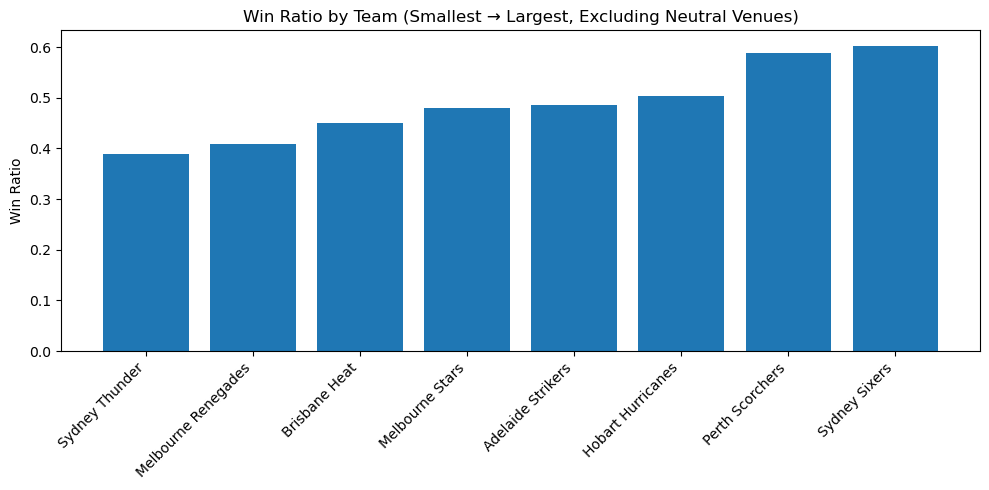

In [4]:
import matplotlib.pyplot as plt
# Sort the dataframe by win_ratio
sorted_df = team_stats_df.sort_values('win_ratio')

plt.figure(figsize=(10,5))
plt.bar(sorted_df['team'], sorted_df['win_ratio'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Win Ratio")
plt.title("Win Ratio by Team (Smallest → Largest, Excluding Neutral Venues)")
plt.tight_layout()
plt.show()


In [5]:
#Home-ground winning ratio for each team
import pandas as pd

matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Keep only matches where the home team is known (remove neutral/hub venues)
home_matches = matches.dropna(subset=['home_team']).copy()
teams = sorted(set(matches['team1']).union(set(matches['team2'])))

home_stats = []

for team in teams:
    # All matches where this team was the home side
    df_home = home_matches[home_matches['home_team'] == team]

    total_home = len(df_home)
    home_wins = (df_home['winner'] == team).sum()

    win_ratio = home_wins / total_home if total_home > 0 else 0

    home_stats.append({
        'team': team,
        'home_matches': total_home,
        'home_wins': home_wins,
        'home_win_ratio': round(win_ratio, 3)
    })

home_stats_df = pd.DataFrame(home_stats)
home_stats_df

home_stats_df.to_csv("Downloads/bbl_cleaned/home_ground_stats.csv", index=False)
print("Saved: home_ground_stats.csv")


Saved: home_ground_stats.csv


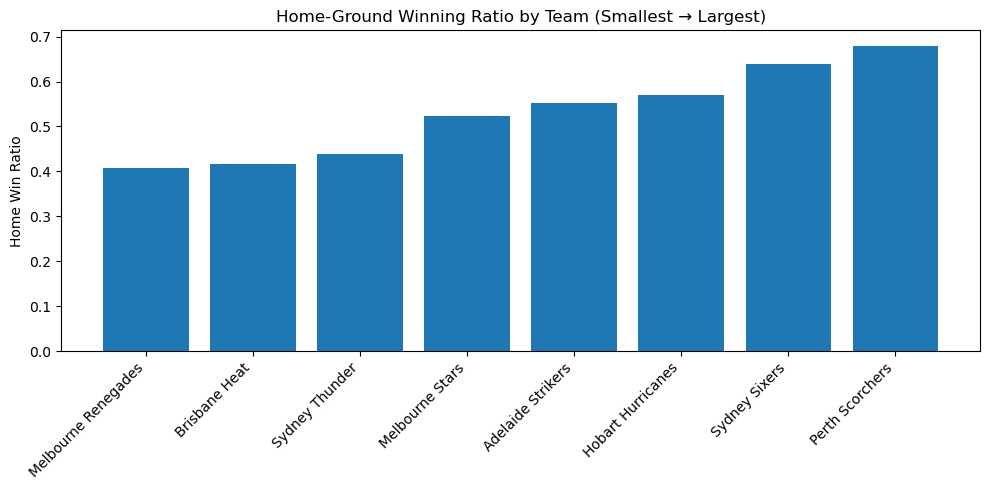

In [6]:
import matplotlib.pyplot as plt

sorted_home = home_stats_df.sort_values("home_win_ratio")

plt.figure(figsize=(10,5))
plt.bar(sorted_home['team'], sorted_home['home_win_ratio'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Home Win Ratio")
plt.title("Home-Ground Winning Ratio by Team (Smallest → Largest)")
plt.tight_layout()
plt.show()


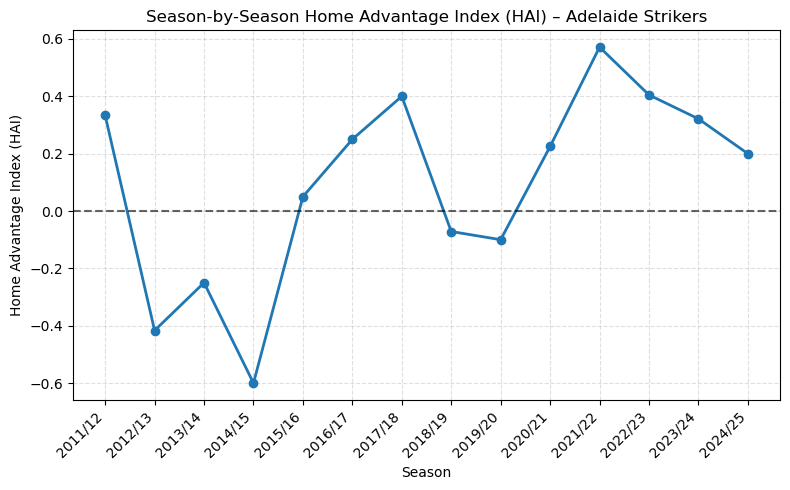

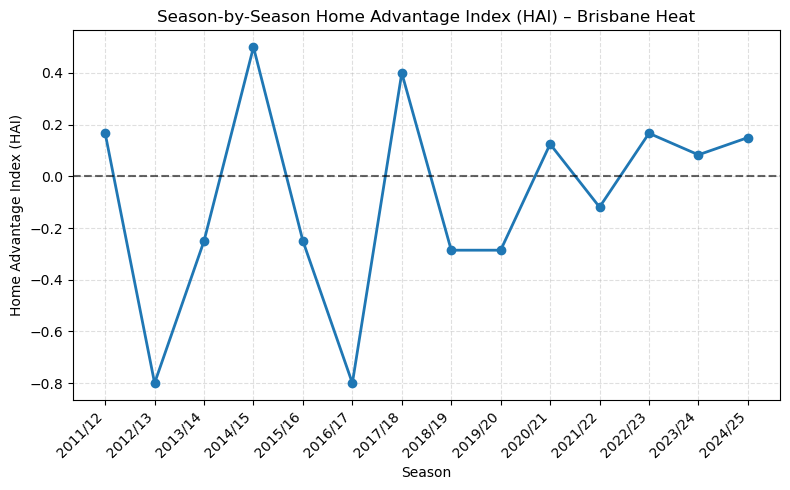

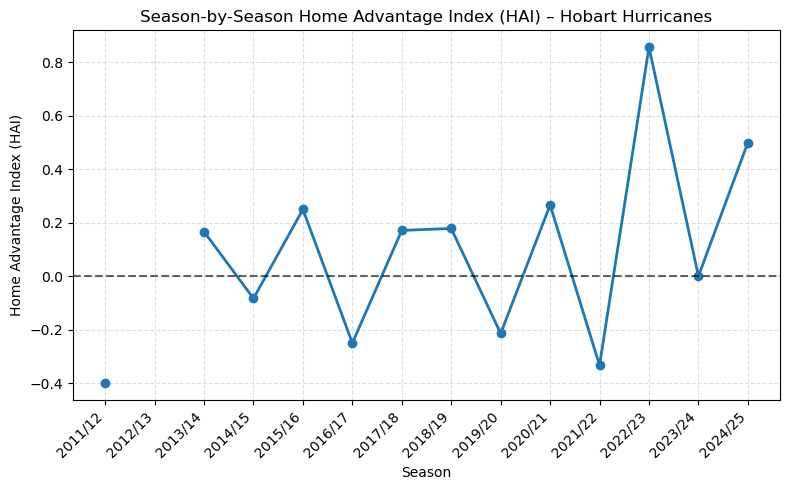

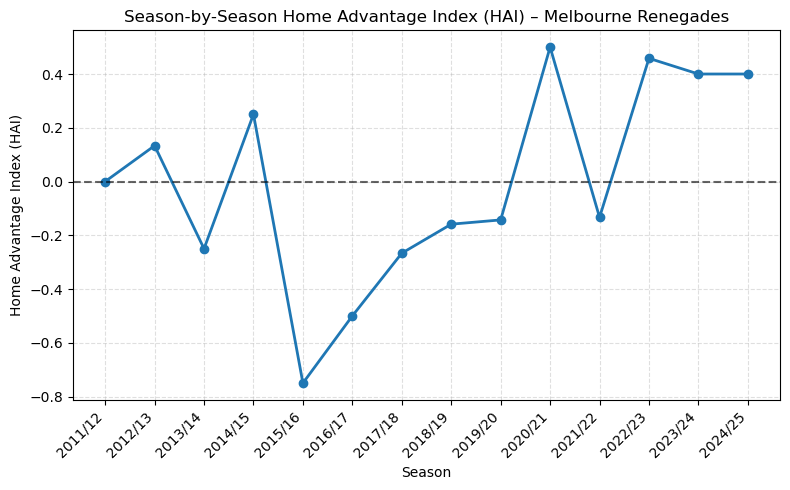

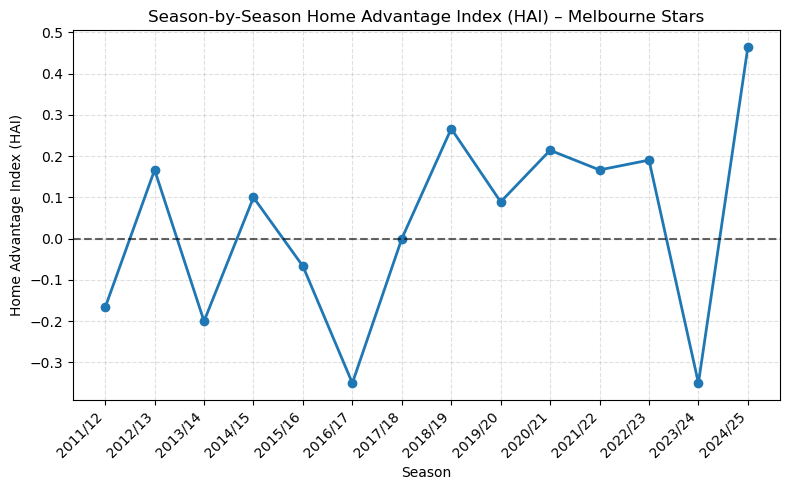

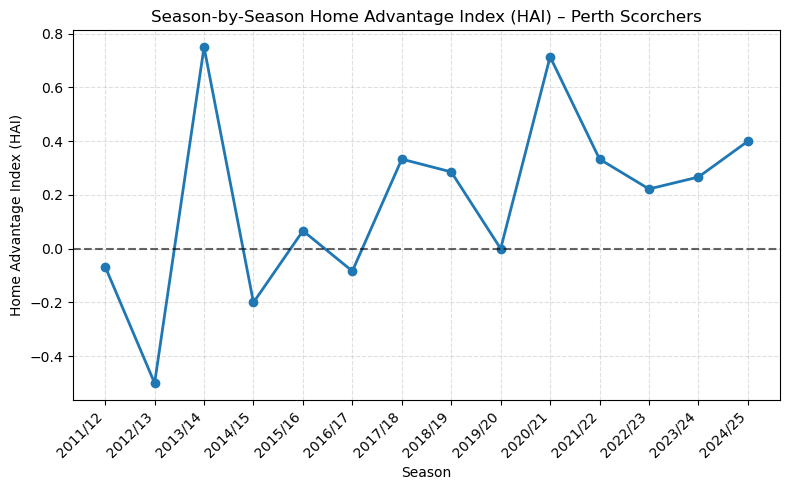

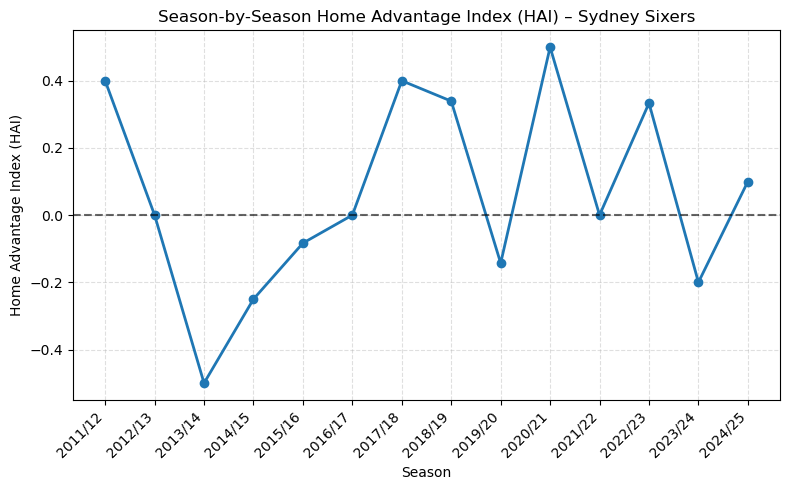

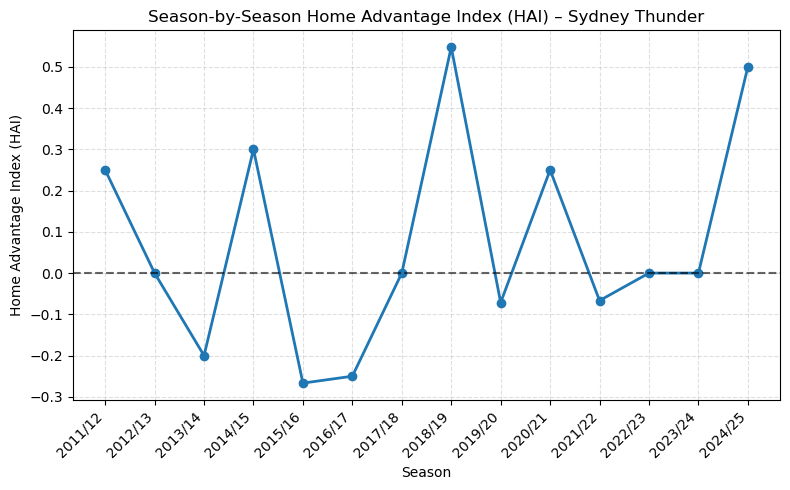

Saved: home_advantage_index.csv


In [7]:
#Home Advantage Index
import pandas as pd

matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
def get_bbl_season(dt):
    if pd.isna(dt):
        return None
    year = dt.year
    if dt.month >= 9:
        start = year
    else:
        start = year - 1
    end_short = str(start + 1)[-2:]
    return f"{start}/{end_short}"

matches['season'] = matches['date'].apply(get_bbl_season)

teams = sorted(set(matches['team1']).union(set(matches['team2'])))

hai_rows = []

for team in teams:
    team_matches = matches[
        (matches['team1'] == team) | (matches['team2'] == team)
    ].copy()

    # Identify home vs away
    team_matches['is_home'] = team_matches['home_team'] == team
    team_matches['is_away'] = team_matches['home_team'].notna() & (team_matches['home_team'] != team)
    
    # Group by season
    grouped = team_matches.groupby('season', dropna=True)

    for season, g in grouped:
        # Home stats
        home_games = g[g['is_home']]
        home_wins = (home_games['winner'] == team).sum()
        home_total = len(home_games)
        home_ratio = home_wins / home_total if home_total > 0 else None

        # Away stats
        away_games = g[g['is_away']]
        away_wins = (away_games['winner'] == team).sum()
        away_total = len(away_games)
        away_ratio = away_wins / away_total if away_total > 0 else None

        # HAI (only if both ratios exist)
        if home_ratio is not None and away_ratio is not None:
            hai = home_ratio - away_ratio
        else:
            hai = None

        hai_rows.append({
            'team': team,
            'season': season,
            'home_win_ratio': home_ratio,
            'away_win_ratio': away_ratio,
            'HAI': hai,
            'home_games': home_total,
            'away_games': away_total
        })

hai_df = pd.DataFrame(hai_rows)

hai_df['season_start'] = hai_df['season'].apply(lambda x: int(x.split('/')[0]))
hai_df = hai_df.sort_values(['team', 'season_start'])
import matplotlib.pyplot as plt

for team in teams:
    df_t = hai_df[hai_df['team'] == team]

    plt.figure(figsize=(8,5))
    plt.plot(df_t['season'], df_t['HAI'], marker='o', linewidth=2)

    plt.axhline(0, color='black', linestyle='--', alpha=0.6)  # baseline: no advantage

    plt.title(f"Season-by-Season Home Advantage Index (HAI) – {team}")
    plt.ylabel("Home Advantage Index (HAI)")
    plt.xlabel("Season")
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

hai_df.to_csv("Downloads/bbl_cleaned/home_advantage_index.csv", index=False)
print("Saved: home_advantage_index.csv")


In [8]:
import pandas as pd

# Load match & HAI data
matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

hai_df = hai_df.copy()   # use the HAI table you created earlier

# Function to get BBL season
def get_bbl_season(dt):
    year = dt.year
    if dt.month >= 9:
        start = year
    else:
        start = year - 1
    return f"{start}/{str(start+1)[-2:]}"

matches['season'] = matches['date'].apply(get_bbl_season)



def diagnose_missing_HAI(team_name):
    print(f"\n===============================")
    print(f"   DIAGNOSTIC REPORT FOR: {team_name}")
    print(f"===============================\n")

    team_hai = hai_df[hai_df['team'] == team_name]

    # Find seasons where HAI is NaN
    missing = team_hai[team_hai['HAI'].isna()]

    if missing.empty:
        print("No missing HAI values — all seasons have valid home/away data.")
        return

    print("Missing HAI detected in seasons:\n")
    print(missing[['season', 'home_games', 'away_games']].to_string(index=False))
    print("\n---------------------------------------------")
    print("Checking reasons for missing HAI...\n")

    for _, row in missing.iterrows():
        season = row['season']
        home = row['home_games']
        away = row['away_games']

        print(f"🔸 SEASON {season}")

        # Case 1: No home games
        if home == 0 and away > 0:
            print("   ❗ No home games played → cannot compute home win ratio.")
            continue
        
        # Case 2: No away games
        if away == 0 and home > 0:
            print("   ❗ No away games played → cannot compute away win ratio.")
            continue

        # Case 3: Neither home nor away (all neutral)
        if home == 0 and away == 0:
            print("   ❗ All matches were at NEUTRAL venues → no home/away data.")
            continue

        # Rare fallback case
        print("   ❗ Missing for an unusual reason — inspect match logs.")

        # Print the raw matches for this season for inspection
        season_matches = matches[
            ((matches['team1'] == team_name) | (matches['team2'] == team_name)) &
            (matches['season'] == season)
        ][['match_id','season','home_team','winner','venue']]

        print("\nAffected matches:")
        print(season_matches.to_string(index=False))
        print()

# Run for Hobart Hurricanes
diagnose_missing_HAI("Hobart Hurricanes")

# Run for all teams (optional)
# for t in sorted(set(matches['team1']).union(set(matches['team2']))):
#     diagnose_missing_HAI(t)



   DIAGNOSTIC REPORT FOR: Hobart Hurricanes

Missing HAI detected in seasons:

 season  home_games  away_games
2012/13           0           4

---------------------------------------------
Checking reasons for missing HAI...

🔸 SEASON 2012/13
   ❗ No home games played → cannot compute home win ratio.


In [9]:
# Cleaning data: remove ties, no-results, bowl-offs, abandoned matches
import pandas as pd

matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

invalid_results = ['no result', 'tie', 'bowl off', 'bowl-off', 'abandoned']
clean_matches = matches[
    (~matches['result'].isin(invalid_results)) &
    (matches['winner'].notna())
].copy()

clean_home_matches = clean_matches.dropna(subset=['home_team']).copy()
teams = sorted(set(clean_matches['team1']).union(set(clean_matches['team2'])))

home_away_rows = []

for team in teams:
    # Home matches: where this team IS the home team
    team_home = clean_home_matches[clean_home_matches['home_team'] == team]
    home_games = len(team_home)
    home_wins  = (team_home['winner'] == team).sum()
    home_win_prob = home_wins / home_games if home_games > 0 else None

    # Away matches: where home_team is known but is NOT this team
    team_away = clean_home_matches[
        ((clean_home_matches['team1'] == team) | (clean_home_matches['team2'] == team)) &
        (clean_home_matches['home_team'] != team)
    ]
    away_games = len(team_away)
    away_wins  = (team_away['winner'] == team).sum()
    away_win_prob = away_wins / away_games if away_games > 0 else None

    home_away_rows.append({
        'team': team,
        'home_games':         home_games,
        'home_wins':          home_wins,
        'home_win_probability': round(home_win_prob, 3) if home_win_prob is not None else None,
        'away_games':         away_games,
        'away_wins':          away_wins,
        'away_win_probability': round(away_win_prob, 3) if away_win_prob is not None else None,
    })

home_away_df = pd.DataFrame(home_away_rows)
# Keep backward-compatible alias
home_prob_df = home_away_df.copy()

home_away_df.to_csv("Downloads/bbl_cleaned/home_away_win_probability.csv", index=False)
print("Saved: home_away_win_probability.csv")
print(home_away_df)


Saved: home_away_win_probability.csv
                  team  home_games  home_wins  home_win_probability  \
0    Adelaide Strikers          75         42                 0.560   
1        Brisbane Heat          70         30                 0.429   
2    Hobart Hurricanes          71         41                 0.577   
3  Melbourne Renegades          75         31                 0.413   
4      Melbourne Stars          64         34                 0.531   
5      Perth Scorchers          75         51                 0.680   
6        Sydney Sixers          68         46                 0.676   
7       Sydney Thunder          64         29                 0.453   

   away_games  away_wins  away_win_probability  
0          66         28                 0.424  
1          72         35                 0.486  
2          68         30                 0.441  
3          66         27                 0.409  
4          79         35                 0.443  
5          69         35     

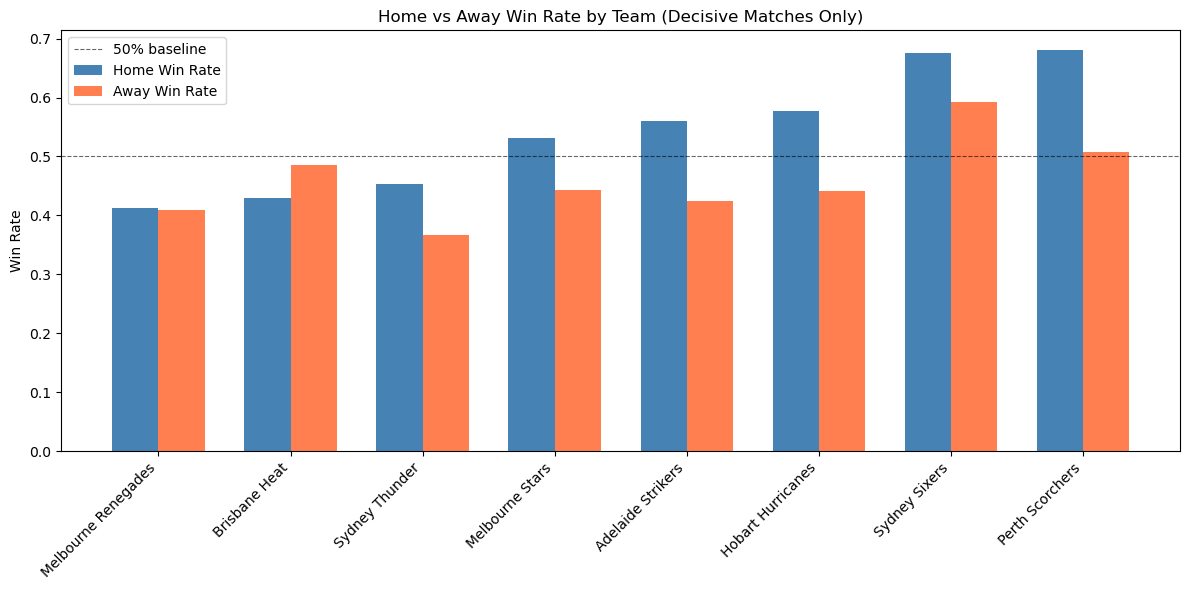

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = home_away_df.dropna(
    subset=['home_win_probability', 'away_win_probability']
).sort_values('home_win_probability').reset_index(drop=True)

x     = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, plot_df['home_win_probability'], width,
       label='Home Win Rate',  color='steelblue')
ax.bar(x + width/2, plot_df['away_win_probability'], width,
       label='Away Win Rate',  color='coral')

ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='50% baseline')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['team'], rotation=45, ha='right')
ax.set_ylabel("Win Rate")
ax.set_title("Home vs Away Win Rate by Team (Decisive Matches Only)")
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
# TWO ROWS PER MATCH — instructor-specified structure.
# Each match generates one row per team so is_home can be a predictor.
# match_id is later used as a random effect to handle paired non-independence.
import pandas as pd

matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

invalid = ['no result', 'tie', 'bowl off', 'bowl-off', 'abandoned']
df = matches[
    (~matches['result'].isin(invalid)) &
    (matches['winner'].notna())
].copy()

rows = []
for _, m in df.iterrows():
    home = m['home_team'] if pd.notna(m['home_team']) else None
    for team, opp in [(m['team1'], m['team2']), (m['team2'], m['team1'])]:
        rows.append({
            'match_id':      m['match_id'],
            'date':          m['date'],
            'team':          team,
            'opponent':      opp,
            'venue':         m['venue'],
            'is_home':       int(home == team) if home else 0,
            'win':           int(m['winner'] == team),
            'toss_winner':   m['toss_winner'],
            'toss_decision': m['toss_decision'],
        })

model_df = pd.DataFrame(rows)
model_df['toss_win'] = (model_df['team'] == model_df['toss_winner']).astype(int)
model_df['toss_bat'] = (
    (model_df['team'] == model_df['toss_winner']) &
    (model_df['toss_decision'] == 'bat')
).astype(int)

model_df.to_csv("Downloads/bbl_cleaned/model_df_step1_tworow.csv", index=False)
print(f"Shape: {model_df.shape}  (two rows per match)")
print(f"Unique matches: {model_df['match_id'].nunique()}")
print(model_df.head(4))


Shape: (1208, 11)  (two rows per match)
Unique matches: 604
   match_id       date             team         opponent  \
0    524915 2011-12-16    Sydney Sixers    Brisbane Heat   
1    524915 2011-12-16    Brisbane Heat    Sydney Sixers   
2    524916 2011-12-17  Melbourne Stars   Sydney Thunder   
3    524916 2011-12-17   Sydney Thunder  Melbourne Stars   

                           venue  is_home  win     toss_winner toss_decision  \
0  Sydney Cricket Ground, Sydney        1    1   Brisbane Heat           bat   
1  Sydney Cricket Ground, Sydney        0    0   Brisbane Heat           bat   
2       Melbourne Cricket Ground        1    0  Sydney Thunder         field   
3       Melbourne Cricket Ground        0    1  Sydney Thunder         field   

   toss_win  toss_bat  
0         0         0  
1         1         1  
2         0         0  
3         1         0  


In [12]:
# ── FEATURE ENGINEERING — rebuilds model_df from scratch ──────────────────
# Saves as model_df_v2.csv for verification before replacing model_df_full.csv
# All historical metrics use ONLY data prior to each match (no data leakage)
import pandas as pd
import numpy as np

BASE = "Downloads/bbl_cleaned/"

# ── Load data ──────────────────────────────────────────────────────────────
model_df = pd.read_csv(BASE + "model_df_step1_tworow.csv")
model_df['date']     = pd.to_datetime(model_df['date'])
model_df['match_id'] = model_df['match_id'].astype(str)

balls = pd.read_csv(BASE + "cleaned_ball_by_ball_data.csv")
balls['date']        = pd.to_datetime(balls['date'])
balls['match_id']    = balls['match_id'].astype(str)

# Infer bowling team: in ball-by-ball, 'team' = batting team
# bowling team = whichever of team1/team2 is NOT batting
balls['bowling_team'] = balls.apply(
    lambda r: r['team2'] if r['team'] == r['team1'] else r['team1'], axis=1
)
print(f"Loaded: model_df {model_df.shape}, balls {balls.shape}")

# ── 1. recent_form_5 ───────────────────────────────────────────────────────
# Win rate in the last 5 completed matches for this team before this match
model_df = model_df.sort_values(['team', 'date']).reset_index(drop=True)
model_df['recent_form_5'] = (
    model_df.groupby('team')['win']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
).fillna(0.5)   # default 0.5 for a team's very first match
print("1. recent_form_5 done")

# ── 2. h2h_win_rate ────────────────────────────────────────────────────────
# Historical win rate of this team against this specific opponent
# Bayesian shrinkage toward 0.5 — low-sample h2h records are pulled toward neutral
# Formula: (wins + k*0.5) / (games + k), where k=5
# e.g. 1 win from 1 game  → 0.58 (not a confident 1.0)
#      8 wins from 10 games → 0.77 (high confidence)
#      0 prior games        → 0.50 (neutral prior)
model_df = model_df.sort_values(['team', 'opponent', 'date']).reset_index(drop=True)

k = 5
model_df['_h2h_wins'] = (
    model_df.groupby(['team', 'opponent'])['win']
    .transform(lambda x: x.shift(1).expanding().sum())
).fillna(0)
model_df['_h2h_games'] = (
    model_df.groupby(['team', 'opponent'])['win']
    .transform(lambda x: x.shift(1).expanding().count())
)
model_df['h2h_win_rate'] = (model_df['_h2h_wins'] + k * 0.5) / (model_df['_h2h_games'] + k)
model_df = model_df.drop(columns=['_h2h_wins', '_h2h_games'])
print("2. h2h_win_rate done (Bayesian shrinkage, k=5)")

# ── 3. Batting familiarity ────────────────────────────────────────────────
# Two distinct metrics capturing different aspects of batting performance:
#   team_bat_sr_familiarity  = batting strike rate at venue (how fast the team scores)
#   team_bat_avg_familiarity = batting average at venue (runs per dismissal — consistency)
# Both use only prior matches to avoid data leakage.
# 'team' in ball-by-ball = batting team — no inference needed.

# Legal balls only (delivery <= 6) for SR; all deliveries for average (balls irrelevant)
legal_balls = balls[balls['delivery'] <= 6]

# Aggregate per match: SR needs runs_batter + legal ball count
#                      Average needs runs_batter + wicket count
bat_agg = (
    legal_balls.groupby(['match_id', 'team'])
    .agg(bat_runs=('runs_batter', 'sum'), bat_balls=('runs_batter', 'count'))
    .reset_index()
    .rename(columns={'team': 'batting_team'})
)
bat_avg_agg = (
    balls.groupby(['match_id', 'team'])
    .agg(bat_runs_avg=('runs_batter', 'sum'), bat_wickets=('wicket', 'sum'))
    .reset_index()
    .rename(columns={'team': 'batting_team'})
)

# Add venue and date from model_df
match_meta = (model_df[['match_id', 'team', 'venue', 'date']]
              .rename(columns={'team': 'batting_team'})
              .drop_duplicates())
bat_agg     = bat_agg.merge(match_meta, on=['match_id', 'batting_team'], how='inner')
bat_avg_agg = bat_avg_agg.merge(match_meta, on=['match_id', 'batting_team'], how='inner')

# ── Batting SR ──────────────────────────────────────────────────────────────
bat_agg = bat_agg.sort_values(['batting_team', 'venue', 'date']).reset_index(drop=True)
bat_agg['cum_bat_runs']  = (bat_agg.groupby(['batting_team', 'venue'])['bat_runs']
                             .transform(lambda x: x.shift(1).expanding().sum()))
bat_agg['cum_bat_balls'] = (bat_agg.groupby(['batting_team', 'venue'])['bat_balls']
                             .transform(lambda x: x.shift(1).expanding().sum()))
bat_agg['team_bat_sr_familiarity'] = bat_agg['cum_bat_runs'] / bat_agg['cum_bat_balls'] * 100

league_bat_sr = legal_balls['runs_batter'].sum() / len(legal_balls) * 100
bat_agg['team_bat_sr_familiarity'] = bat_agg['team_bat_sr_familiarity'].fillna(league_bat_sr)

model_df = model_df.merge(
    bat_agg[['match_id', 'batting_team', 'team_bat_sr_familiarity']]
    .rename(columns={'batting_team': 'team'}),
    on=['match_id', 'team'], how='left'
)
print(f"3a. team_bat_sr_familiarity done — range: "
      f"{model_df['team_bat_sr_familiarity'].min():.1f} to "
      f"{model_df['team_bat_sr_familiarity'].max():.1f}, "
      f"mean: {model_df['team_bat_sr_familiarity'].mean():.2f}")

# ── Batting Average ─────────────────────────────────────────────────────────
bat_avg_agg = bat_avg_agg.sort_values(['batting_team', 'venue', 'date']).reset_index(drop=True)
bat_avg_agg['cum_bat_runs_avg'] = (
    bat_avg_agg.groupby(['batting_team', 'venue'])['bat_runs_avg']
    .transform(lambda x: x.shift(1).expanding().sum())
)
bat_avg_agg['cum_bat_wickets'] = (
    bat_avg_agg.groupby(['batting_team', 'venue'])['bat_wickets']
    .transform(lambda x: x.shift(1).expanding().sum())
)

# Average = runs / wickets; 0 prior wickets → fill with league-wide average
league_bat_avg = balls['runs_batter'].sum() / balls['wicket'].sum()
bat_avg_agg['team_bat_avg_familiarity'] = (
    (bat_avg_agg['cum_bat_runs_avg'] /
     bat_avg_agg['cum_bat_wickets'].replace(0, np.nan))
    .fillna(league_bat_avg)
)

model_df = model_df.merge(
    bat_avg_agg[['match_id', 'batting_team', 'team_bat_avg_familiarity']]
    .rename(columns={'batting_team': 'team'}),
    on=['match_id', 'team'], how='left'
)
print(f"3b. team_bat_avg_familiarity done — range: "
      f"{model_df['team_bat_avg_familiarity'].min():.1f} to "
      f"{model_df['team_bat_avg_familiarity'].max():.1f}, "
      f"mean: {model_df['team_bat_avg_familiarity'].mean():.2f}")

# ── 4. Bowling familiarity ─────────────────────────────────────────────────
# Economy rate and bowling SR at this venue in all PRIOR matches
# Uses correctly inferred bowling_team — handles player transfers automatically
bowl_agg = (
    balls.groupby(['match_id', 'bowling_team'])
    .agg(
        bowl_runs   =('runs_total', 'sum'),
        bowl_balls  =('runs_total', 'count'),
        bowl_wickets=('wicket', 'sum')
    )
    .reset_index()
)

# Add venue and date (bowling_team maps to 'team' column in model_df)
match_meta_bowl = (model_df[['match_id', 'team', 'venue', 'date']]
                   .rename(columns={'team': 'bowling_team'})
                   .drop_duplicates())
bowl_agg = bowl_agg.merge(match_meta_bowl, on=['match_id', 'bowling_team'], how='inner')

# Sort and compute cumulative bowling stats at this venue, excluding current match
bowl_agg = bowl_agg.sort_values(['bowling_team', 'venue', 'date']).reset_index(drop=True)
for col in ['bowl_runs', 'bowl_balls', 'bowl_wickets']:
    bowl_agg[f'cum_{col}'] = (bowl_agg.groupby(['bowling_team', 'venue'])[col]
                               .transform(lambda x: x.shift(1).expanding().sum()))

# Economy rate = runs conceded per over (all deliveries, including extras)
bowl_agg['raw_eco']     = bowl_agg['cum_bowl_runs'] / (bowl_agg['cum_bowl_balls'] / 6)
# Bowling SR = balls bowled per wicket (0 wickets → NaN, filled with league default)
bowl_agg['raw_bowl_sr'] = (bowl_agg['cum_bowl_balls']
                            / bowl_agg['cum_bowl_wickets'].replace(0, np.nan))

# Negate: stored negative so that HIGHER (closer to 0) = BETTER bowling
league_eco     = balls['runs_total'].sum() / (len(balls) / 6)
league_bowl_sr = len(balls) / balls['wicket'].sum()

bowl_agg['team_bowl_eco_familiarity'] = (-bowl_agg['raw_eco']).fillna(-league_eco)
bowl_agg['team_bowl_sr_familiarity']  = (-bowl_agg['raw_bowl_sr']).fillna(-league_bowl_sr)

model_df = model_df.merge(
    bowl_agg[['match_id', 'bowling_team',
              'team_bowl_eco_familiarity', 'team_bowl_sr_familiarity']]
    .rename(columns={'bowling_team': 'team'}),
    on=['match_id', 'team'], how='left'
)
print(f"4. bowling familiarity done — eco range: "
      f"{model_df['team_bowl_eco_familiarity'].min():.2f} to "
      f"{model_df['team_bowl_eco_familiarity'].max():.2f}, "
      f"mean: {model_df['team_bowl_eco_familiarity'].mean():.2f}")
print(f"   bowl_sr range: "
      f"{model_df['team_bowl_sr_familiarity'].min():.2f} to "
      f"{model_df['team_bowl_sr_familiarity'].max():.2f}, "
      f"mean: {model_df['team_bowl_sr_familiarity'].mean():.2f}")

# ── 5. pp_rr_lag5 ─────────────────────────────────────────────────────────
# Team's batting powerplay run rate in their last 5 matches
# Use over <= 6 (first 6 overs) consistently across all seasons
# BBL powerplay rules changed over the dataset: using over <= 6 avoids inconsistency
pp_balls = balls[balls['over'] <= 6].copy()
pp_agg = (
    pp_balls.groupby(['match_id', 'team'])
    .agg(pp_runs=('runs_total', 'sum'), pp_balls_count=('runs_total', 'count'))
    .reset_index()
    .rename(columns={'team': 'batting_team'})
)
pp_agg['pp_rr'] = pp_agg['pp_runs'] / (pp_agg['pp_balls_count'] / 6)

# Add date for sorting
pp_agg = pp_agg.merge(
    model_df[['match_id', 'team', 'date']].rename(columns={'team': 'batting_team'}).drop_duplicates(),
    on=['match_id', 'batting_team'], how='inner'
)

# Rolling 5-match average of powerplay run rate, prior to current match
pp_agg = pp_agg.sort_values(['batting_team', 'date']).reset_index(drop=True)
pp_agg['pp_rr_lag5'] = (
    pp_agg.groupby('batting_team')['pp_rr']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Default: league-wide average powerplay run rate for first-match rows
league_pp_rr = pp_agg['pp_rr'].mean()
pp_agg['pp_rr_lag5'] = pp_agg['pp_rr_lag5'].fillna(league_pp_rr)

model_df = model_df.merge(
    pp_agg[['match_id', 'batting_team', 'pp_rr_lag5']]
    .rename(columns={'batting_team': 'team'}),
    on=['match_id', 'team'], how='left'
)
print(f"5. pp_rr_lag5 done — range: "
      f"{model_df['pp_rr_lag5'].min():.2f} to "
      f"{model_df['pp_rr_lag5'].max():.2f}, "
      f"mean: {model_df['pp_rr_lag5'].mean():.2f}")

# ── 6. Save and compare ────────────────────────────────────────────────────
final_cols = [
    'match_id', 'team', 'opponent', 'date', 'is_home', 'toss_win', 'toss_bat', 'win',
    'recent_form_5', 'h2h_win_rate',
    'team_bat_sr_familiarity', 'team_bat_avg_familiarity',
    'team_bowl_eco_familiarity', 'team_bowl_sr_familiarity',
    'pp_rr_lag5'
]
model_df_v2 = model_df[final_cols].copy()
model_df_v2 = model_df_v2.sort_values(['date', 'match_id', 'team']).reset_index(drop=True)

print(f"\nFinal shape: {model_df_v2.shape}  (expected 1208 rows)")
print(f"Nulls: {model_df_v2.isnull().sum().sum()}")
print(f"Columns: {model_df_v2.columns.tolist()}")
model_df_v2.to_csv(BASE + "model_df_v2.csv", index=False)
print("Saved: model_df_v2.csv")

# Quick sanity check: compare key stats with original model_df_full.csv
original = pd.read_csv(BASE + "model_df_full.csv")
original['match_id'] = original['match_id'].astype(str)
cmp = model_df_v2.merge(original, on=['match_id', 'team'], suffixes=('_v2', '_orig'))
print("\n=== Comparison: v2 vs original model_df_full ===")
for feat in ['recent_form_5', 'h2h_win_rate', 'team_bat_sr_familiarity',
             'team_bowl_eco_familiarity', 'team_bowl_sr_familiarity', 'pp_rr_lag5']:
    orig_col = f'{feat}_orig' if f'{feat}_orig' in cmp.columns else feat
    v2_col   = f'{feat}_v2'   if f'{feat}_v2'   in cmp.columns else feat
    if orig_col in cmp.columns and v2_col in cmp.columns:
        corr = cmp[v2_col].corr(cmp[orig_col])
        v2_mean   = cmp[v2_col].mean()
        orig_mean = cmp[orig_col].mean()
        print(f"  {feat}: corr={corr:.3f}  v2_mean={v2_mean:.3f}  orig_mean={orig_mean:.3f}")

print(model_df_v2.tail(20))

Loaded: model_df (1208, 11), balls (143323, 24)
1. recent_form_5 done
2. h2h_win_rate done (Bayesian shrinkage, k=5)
3a. team_bat_sr_familiarity done — range: 72.5 to 196.2, mean: 123.51
3b. team_bat_avg_familiarity done — range: 8.3 to 174.0, mean: 24.99
4. bowling familiarity done — eco range: -10.15 to -4.58, mean: -7.76
   bowl_sr range: -88.00 to -8.75, mean: -19.83
5. pp_rr_lag5 done — range: 3.41 to 11.05, mean: 7.34

Final shape: (1208, 15)  (expected 1208 rows)
Nulls: 0
Columns: ['match_id', 'team', 'opponent', 'date', 'is_home', 'toss_win', 'toss_bat', 'win', 'recent_form_5', 'h2h_win_rate', 'team_bat_sr_familiarity', 'team_bat_avg_familiarity', 'team_bowl_eco_familiarity', 'team_bowl_sr_familiarity', 'pp_rr_lag5']
Saved: model_df_v2.csv

=== Comparison: v2 vs original model_df_full ===
  recent_form_5: corr=1.000  v2_mean=0.501  orig_mean=0.501
  h2h_win_rate: corr=0.899  v2_mean=0.500  orig_mean=0.500
  team_bat_sr_familiarity: corr=0.178  v2_mean=123.514  orig_mean=124.524

In [13]:
import statsmodels.formula.api as smf
import numpy as np

# M1: Baseline — does playing at home affect win probability?
m1 = smf.logit("win ~ is_home", data=model_df).fit(method='bfgs', maxiter=300, disp=False)
print("=== M1: Baseline Logit (is_home only) ===")
print(f"Converged: {m1.mle_retvals['converged']}")
print(m1.summary())

# Interpret
beta0 = m1.params['Intercept']
beta1 = m1.params['is_home']
logistic = lambda x: 1/(1+np.exp(-x))
p_away = logistic(beta0)
p_home = logistic(beta0 + beta1)
print(f"\nAway/neutral win probability: {p_away:.3f}")
print(f"Home win probability:          {p_home:.3f}")
print(f"Home advantage (difference):  {p_home - p_away:+.3f}")
print(f"Odds ratio for is_home:        {np.exp(beta1):.4f}")


=== M1: Baseline Logit (is_home only) ===
Converged: True
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1206
Method:                           MLE   Df Model:                            1
Date:                Sun, 10 May 2026   Pseudo R-squ.:                0.004208
Time:                        01:10:23   Log-Likelihood:                -833.80
converged:                       True   LL-Null:                       -837.32
Covariance Type:            nonrobust   LLR p-value:                  0.007937
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1427      0.079     -1.809      0.070      -0.297       0.012
is_home        0.3068      0.116      2.651      0.008       0.080       

In [14]:
# Load the full feature set (pre-built with familiarity + pp run rate)
# This file was generated by the feature engineering pipeline.
import pandas as pd

model_df = pd.read_csv("Downloads/bbl_cleaned/model_df_v2.csv")
model_df['match_id'] = model_df['match_id'].astype(str)
model_df['date'] = pd.to_datetime(model_df['date'], errors='coerce')

print(f"Shape: {model_df.shape}  (two rows per match)")
print(f"Unique matches: {model_df['match_id'].nunique()}")
print(f"Columns: {list(model_df.columns)}")
print(f"Nulls: {model_df.isnull().sum().sum()}")
print(model_df[['team','is_home','toss_win','recent_form_5',
                'h2h_win_rate','pp_rr_lag5','team_bat_sr_familiarity','win']].head(4))


Shape: (1208, 15)  (two rows per match)
Unique matches: 604
Columns: ['match_id', 'team', 'opponent', 'date', 'is_home', 'toss_win', 'toss_bat', 'win', 'recent_form_5', 'h2h_win_rate', 'team_bat_sr_familiarity', 'team_bat_avg_familiarity', 'team_bowl_eco_familiarity', 'team_bowl_sr_familiarity', 'pp_rr_lag5']
Nulls: 0
              team  is_home  toss_win  recent_form_5  h2h_win_rate  \
0    Brisbane Heat        0         1            0.5           0.5   
1    Sydney Sixers        1         0            0.5           0.5   
2  Melbourne Stars        1         0            0.5           0.5   
3   Sydney Thunder        0         1            0.5           0.5   

   pp_rr_lag5  team_bat_sr_familiarity  win  
0    7.368825               124.413971    0  
1    7.368825               124.413971    1  
2    7.368825               124.413971    0  
3    7.368825               124.413971    1  


In [15]:
import pandas as pd
balls = pd.read_csv("Downloads/bbl_cleaned/cleaned_ball_by_ball_data.csv")
print(f"Balls shape: {balls.shape}")
print(balls.columns.tolist())


Balls shape: (143323, 23)
['match_id', 'date', 'team1', 'team2', 'home_team', 'winner', 'result', 'winner_by_runs', 'winner_by_wickets', 'innings', 'team', 'over', 'delivery', 'batter', 'bowler', 'runs_batter', 'runs_total', 'wicket', 'wicket_type', 'wicket_player_out', 'powerplay', 'powerplay_type', 'venue']


In [16]:
import statsmodels.formula.api as smf
import numpy as np
import warnings
warnings.filterwarnings('ignore')

m2 = smf.logit(
    """win ~ is_home + toss_win + toss_bat + recent_form_5
        + h2h_win_rate + pp_rr_lag5
        + team_bat_sr_familiarity + team_bat_avg_familiarity
        + team_bowl_eco_familiarity + team_bowl_sr_familiarity""",
    data=model_df
).fit(method='bfgs', maxiter=300, disp=False)

print("=== M2: Full Logistic Regression ===")
print(f"Converged: {m2.mle_retvals['converged']}")
print(m2.summary())

# Odds ratios
or_df = np.exp(m2.params).rename('Odds Ratio').to_frame()
or_df['95% CI Lower'] = np.exp(m2.conf_int()[0])
or_df['95% CI Upper'] = np.exp(m2.conf_int()[1])
or_df['p-value']      = m2.pvalues
print("\n=== Odds Ratios ===")
print(or_df.round(4).to_string())


=== M2: Full Logistic Regression ===
Converged: True
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1197
Method:                           MLE   Df Model:                           10
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.01503
Time:                        01:10:24   Log-Likelihood:                -824.74
converged:                       True   LL-Null:                       -837.32
Covariance Type:            nonrobust   LLR p-value:                  0.005027
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -2.9845      1.093     -2.730      0.006      -5.127      -0.842
is_home                       0.3

In [17]:
from itertools import combinations
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

predictors = [
    "is_home", "toss_win", "toss_bat", "recent_form_5",
    "h2h_win_rate", "pp_rr_lag5",
    "team_bat_sr_familiarity", "team_bat_avg_familiarity",
    "team_bowl_eco_familiarity", "team_bowl_sr_familiarity",
]

X = model_df[predictors].copy()
pairs = list(combinations(predictors, 2))
interaction_names = [f"{a}:{b}" for a, b in pairs]
X_int = pd.DataFrame({n: X[a]*X[b] for n,(a,b) in zip(interaction_names, pairs)})

scaler = StandardScaler()
X_int_scaled = scaler.fit_transform(X_int)
y = model_df["win"].values

# L1 LASSO — moderate sparsity (C=0.05)
lasso = LogisticRegression(penalty="l1", solver="liblinear", C=0.05, max_iter=1000, random_state=42)
lasso.fit(X_int_scaled, y)

nonzero_mask = lasso.coef_[0] != 0
selected_interaction_names = [interaction_names[i] for i in range(len(interaction_names)) if nonzero_mask[i]]

if not selected_interaction_names:
    abs_coefs = np.abs(lasso.coef_[0])
    top3 = np.argsort(abs_coefs)[-3:][::-1]
    selected_interaction_names = [interaction_names[i] for i in top3]
    print("LASSO zeroed all interactions — using top-3 by magnitude:")
else:
    print(f"LASSO selected {len(selected_interaction_names)} interaction(s):")

for term in selected_interaction_names:
    idx = interaction_names.index(term)
    print(f"  {term}  (coef={lasso.coef_[0][idx]:.4f})")


LASSO selected 7 interaction(s):
  is_home:toss_win  (coef=0.0258)
  is_home:recent_form_5  (coef=0.1096)
  toss_win:h2h_win_rate  (coef=0.0158)
  recent_form_5:h2h_win_rate  (coef=0.0318)
  h2h_win_rate:team_bat_sr_familiarity  (coef=0.0004)
  h2h_win_rate:team_bowl_eco_familiarity  (coef=-0.0797)
  team_bat_sr_familiarity:team_bowl_eco_familiarity  (coef=-0.0231)


In [18]:
import statsmodels.formula.api as smf
import numpy as np

# Build formula using ':' (interaction-only — main effects already included)
interaction_terms = "\n        + ".join(selected_interaction_names)
formula_m3 = (
    "win ~ is_home + toss_win + toss_bat + recent_form_5"
    " + h2h_win_rate + pp_rr_lag5"
    " + team_bat_sr_familiarity + team_bat_avg_familiarity"
    " + team_bowl_eco_familiarity + team_bowl_sr_familiarity"
    f"\n        + {interaction_terms}"
)

m3 = smf.logit(formula_m3, data=model_df).fit(method='newton', maxiter=300, disp=False)
print("=== M3: Full Logit + LASSO-selected Interactions ===")
print(f"Converged: {m3.mle_retvals['converged']}")
print(m3.summary())

or_df3 = np.exp(m3.params).rename('Odds Ratio').to_frame()
or_df3['95% CI Lower'] = np.exp(m3.conf_int()[0])
or_df3['95% CI Upper'] = np.exp(m3.conf_int()[1])
or_df3['p-value']      = m3.pvalues
print("\n=== Odds Ratios (M3) ===")
print(or_df3.round(4).to_string())


=== M3: Full Logit + LASSO-selected Interactions ===
Converged: True
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1190
Method:                           MLE   Df Model:                           17
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.01808
Time:                        01:10:24   Log-Likelihood:                -822.18
converged:                       True   LL-Null:                       -837.32
Covariance Type:            nonrobust   LLR p-value:                   0.02439
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             5.5296   

In [19]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# M4: Random intercepts for team AND match_id
# (1|team)     — between-team ability differences
# (1|match_id) — non-independence of the two rows per match
formula_fixed = (
    "win ~ is_home + toss_win + toss_bat + recent_form_5"
    " + h2h_win_rate + pp_rr_lag5"
    " + team_bat_sr_familiarity + team_bat_avg_familiarity"
    " + team_bowl_eco_familiarity + team_bowl_sr_familiarity"
)

vc_formulas = {
    "team":  "0 + C(team)",
    "match": "0 + C(match_id)",
}

glmm = BinomialBayesMixedGLM.from_formula(formula_fixed, vc_formulas, data=model_df)
m4 = glmm.fit_vb()

print("=== M4: Bayesian Mixed-Effects GLMM ===")
print("Random effects: (1|team) + (1|match_id)")
print(m4.summary())

print("\nFixed-effect Odds Ratios (posterior mean):")
for name, coef in zip(m4.model.exog_names, m4.params[:len(m4.model.exog_names)]):
    print(f"  {name:<35}  OR = {np.exp(coef):.4f}  (log-odds = {coef:.4f})")

print("\nRandom-effect SD estimates:")
print(f"  team  SD: {np.exp(m4.params[-2]):.4f}  — between-team variability")
print(f"  match SD: {np.exp(m4.params[-1]):.4f}  — within-match pairing correlation")


=== M4: Bayesian Mixed-Effects GLMM ===
Random effects: (1|team) + (1|match_id)
                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M    -2.3975   0.0584                      
is_home                      M     0.3375   0.0856                      
toss_win                     M     0.2236   0.0827                      
toss_bat                     M    -0.1059   0.1291                      
recent_form_5                M     0.2601   0.1049                      
h2h_win_rate                 M     0.5009   0.1140                      
pp_rr_lag5                   M    -0.0057   0.0079                      
team_bat_sr_familiarity      M     0.0055   0.0005                      
team_bat_avg_familiarity     M    -0.0025   0.0022                      
team_bowl_eco_familiarity    M    -0.1424   0.0075                 

In [20]:
# M5: lme4 glmer — gold-standard mixed-effects logistic regression
# (1|team) + (1|match_id) random intercepts
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pandas2ri.activate()
importr('lme4')

ro.globalenv['df_r'] = pandas2ri.py2rpy(model_df)

ro.r('''
suppressMessages(library(lme4))
glmm_model <- glmer(
    win ~ is_home + toss_win + toss_bat + recent_form_5
        + h2h_win_rate + pp_rr_lag5
        + team_bat_sr_familiarity + team_bat_avg_familiarity
        + team_bowl_eco_familiarity + team_bowl_sr_familiarity
        + (1 | team) + (1 | match_id),
    data = df_r,
    family = binomial(link = "logit"),
    control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e5))
)
''')

print("=== M5: lme4 glmer — Mixed-Effects Logistic Regression ===")
print("Random intercepts: (1|team) + (1|match_id)")
print(ro.r('summary(glmm_model)'))

# Fixed-effect Odds Ratios with Wald CIs
fixef    = list(ro.r('fixef(glmm_model)'))
names    = list(ro.r('names(fixef(glmm_model))'))
or_vals  = np.exp(fixef)
ci_arr   = np.array(ro.r('exp(confint(glmm_model, method="Wald"))'))
ci_names = list(ro.r('rownames(confint(glmm_model, method="Wald"))'))

print("\nFixed-effect Odds Ratios (95% Wald CIs):")
print(f"{'Predictor':<35} {'OR':>8}  {'CI Lower':>10}  {'CI Upper':>10}")
print('-' * 68)
for i, name in enumerate(names):
    if name in ci_names:
        j = ci_names.index(name)
        print(f"{name:<35} {or_vals[i]:>8.4f}  {ci_arr[j,0]:>10.4f}  {ci_arr[j,1]:>10.4f}")
    else:
        print(f"{name:<35} {or_vals[i]:>8.4f}")

print("\nRandom Effects Variance Components:")
print(ro.r('as.data.frame(VarCorr(glmm_model))'))

is_singular = bool(ro.r('isSingular(glmm_model)')[0])
if is_singular:
    print("\nNote: Singular fit — random effect variances = 0.")
    print("After controlling for fixed effects (especially familiarity features),")
    print("no residual between-team or within-match clustering remains.")
    print("The fixed-effects models (M2/M3) are adequate as final models.")


R[write to console]: boundary (singular) fit: see help('isSingular')



=== M5: lme4 glmer — Mixed-Effects Logistic Regression ===
Random intercepts: (1|team) + (1|match_id)
Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: win ~ is_home + toss_win + toss_bat + recent_form_5 + h2h_win_rate +  
    pp_rr_lag5 + team_bat_sr_familiarity + team_bat_avg_familiarity +  
    team_bowl_eco_familiarity + team_bowl_sr_familiarity + (1 |  
    team) + (1 | match_id)
   Data: df_r
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e+05))

     AIC      BIC   logLik deviance df.resid 
  1671.9   1738.2   -822.9   1645.9     1195 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.53390 -0.96723  0.00167  0.96492  1.48858 

Random effects:
 Groups   Name        Variance Std.Dev.
 match_id (Intercept) 0.00000  0.0000  
 team     (Intercept) 0.04714  0.2171  
Number of obs: 1208, groups:  match_id, 604; team, 8

Fixed effects:
                           Es

Train: 1048 rows | Test: 160 rows


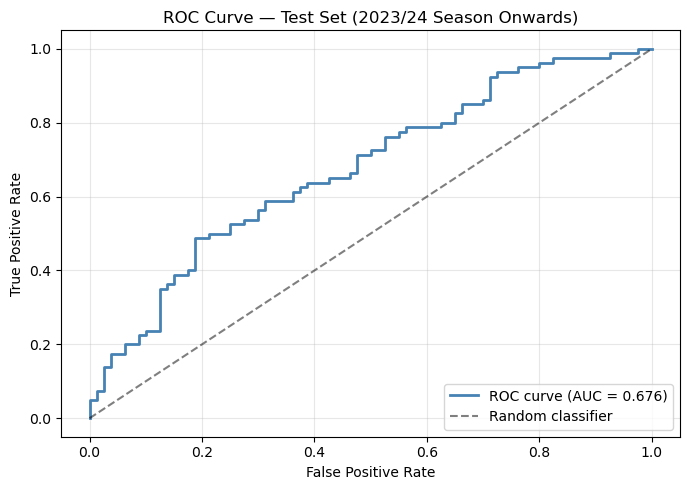

AUC: 0.6761


In [21]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Temporal split: train on pre-2023/24, test on 2023/24 onwards
cutoff = pd.Timestamp("2023-10-01")
train_df = model_df[model_df['date'] < cutoff].copy()
test_df  = model_df[model_df['date'] >= cutoff].copy()
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

formula = (
    "win ~ is_home + toss_win + toss_bat + recent_form_5"
    " + h2h_win_rate + pp_rr_lag5"
    " + team_bat_sr_familiarity + team_bat_avg_familiarity"
    " + team_bowl_eco_familiarity + team_bowl_sr_familiarity"
)
train_model = smf.logit(formula, data=train_df).fit(method='bfgs', maxiter=300, disp=False)

test_pred_prob = train_model.predict(test_df)
test_actual    = test_df['win'].values

fpr, tpr, _ = roc_curve(test_actual, test_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set (2023/24 Season Onwards)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/roc_curve.png", dpi=150)
plt.show()
print(f"AUC: {roc_auc:.4f}")


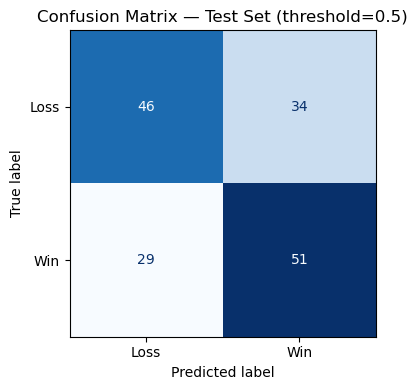

              precision    recall  f1-score   support

        Loss       0.61      0.57      0.59        80
         Win       0.60      0.64      0.62        80

    accuracy                           0.61       160
   macro avg       0.61      0.61      0.61       160
weighted avg       0.61      0.61      0.61       160



In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

threshold = 0.5
test_pred_class = (test_pred_prob >= threshold).astype(int)

cm = confusion_matrix(test_actual, test_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss", "Win"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set (threshold=0.5)")
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(test_actual, test_pred_class, target_names=["Loss","Win"]))


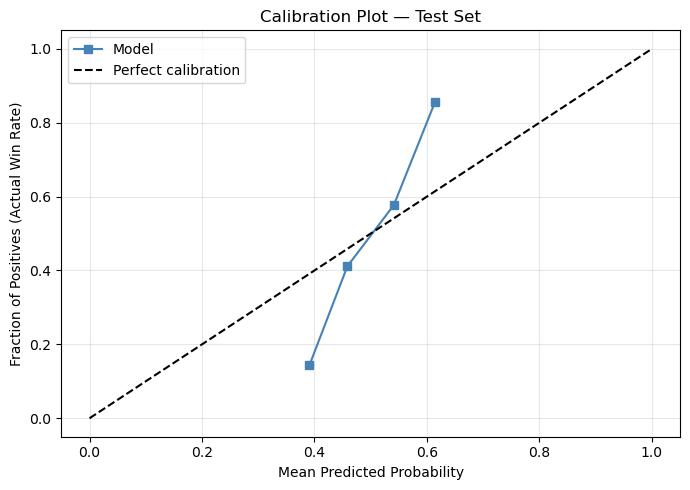

In [23]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fraction_of_positives, mean_predicted_value = calibration_curve(
    test_actual, test_pred_prob, n_bins=10, strategy="uniform"
)

plt.figure(figsize=(7, 5))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color="steelblue", label="Model")
plt.plot([0,1],[0,1],"k--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual Win Rate)")
plt.title("Calibration Plot — Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/calibration_plot.png", dpi=150)
plt.show()


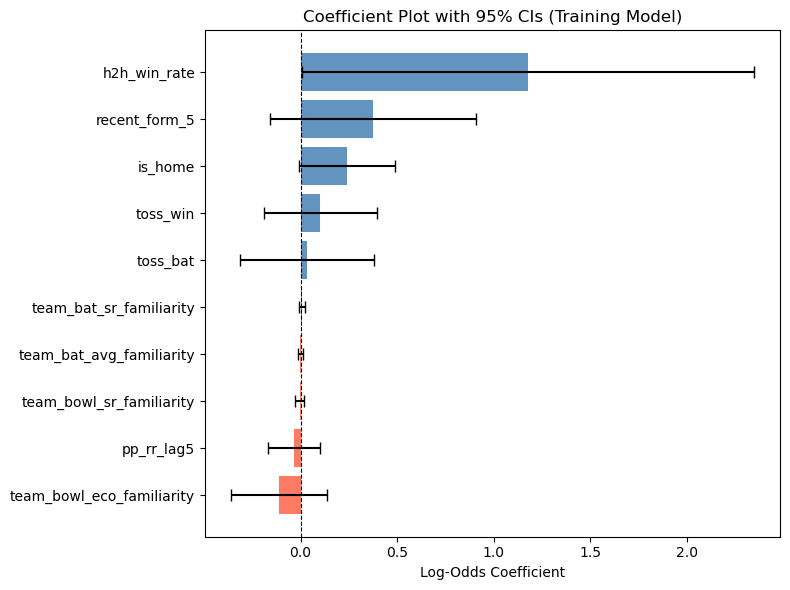

In [24]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

coef_df = pd.DataFrame({
    "coef":    train_model.params,
    "ci_low":  train_model.conf_int()[0],
    "ci_high": train_model.conf_int()[1],
}).drop("Intercept", errors="ignore")

coef_df = coef_df.sort_values("coef")
coef_df["err_low"]  = coef_df["coef"] - coef_df["ci_low"]
coef_df["err_high"] = coef_df["ci_high"] - coef_df["coef"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coef_df.index, coef_df["coef"],
        xerr=[coef_df["err_low"], coef_df["err_high"]],
        color=["steelblue" if c > 0 else "tomato" for c in coef_df["coef"]],
        capsize=4, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Log-Odds Coefficient")
ax.set_title("Coefficient Plot with 95% CIs (Training Model)")
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/coefficient_plot.png", dpi=150)
plt.show()


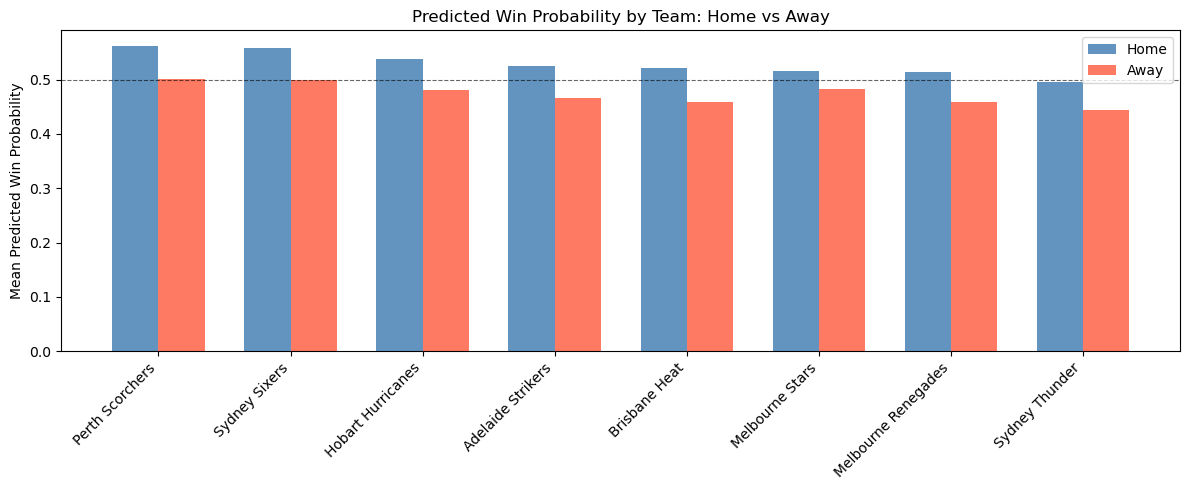

In [25]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

model_df["pred_prob"] = train_model.predict(model_df)

team_probs = model_df.groupby(["team", "is_home"])["pred_prob"].mean().unstack()
team_probs.columns = ["Away", "Home"]
team_probs = team_probs.sort_values("Home", ascending=False)

x = np.arange(len(team_probs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, team_probs["Home"], width, label="Home",  color="steelblue", alpha=0.85)
ax.bar(x + width/2, team_probs["Away"], width, label="Away",  color="tomato",    alpha=0.85)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(team_probs.index, rotation=45, ha="right")
ax.set_ylabel("Mean Predicted Win Probability")
ax.set_title("Predicted Win Probability by Team: Home vs Away")
ax.legend()
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/team_pred_prob.png", dpi=150)
plt.show()


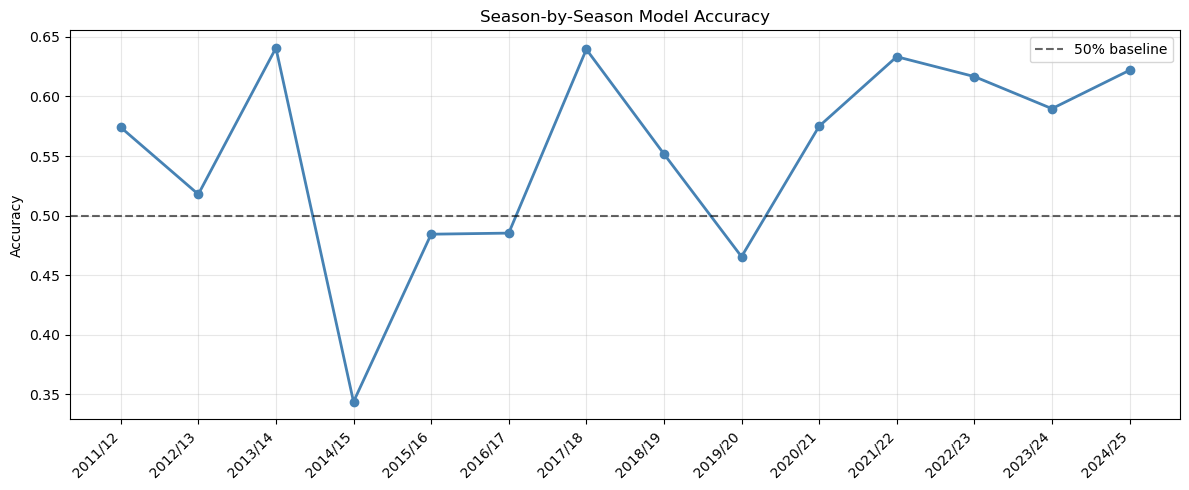

 season  accuracy
2011/12  0.574074
2012/13  0.517857
2013/14  0.640625
2014/15  0.343750
2015/16  0.484375
2016/17  0.485294
2017/18  0.639535
2018/19  0.551724
2019/20  0.465517
2020/21  0.575000
2021/22  0.633333
2022/23  0.616667
2023/24  0.589744
2024/25  0.621951


In [26]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sklearn.metrics import accuracy_score

def get_bbl_season(dt):
    if pd.isna(dt): return None
    y = dt.year
    start = y if dt.month >= 9 else y - 1
    return f"{start}/{str(start+1)[-2:]}"

model_df["season"] = model_df["date"].apply(get_bbl_season)
model_df["pred_class"] = (model_df["pred_prob"] >= 0.5).astype(int)

season_acc = (
    model_df.dropna(subset=["season"])
    .groupby("season")
    .apply(lambda g: accuracy_score(g["win"], g["pred_class"]))
    .reset_index(name="accuracy")
)

plt.figure(figsize=(12, 5))
plt.plot(season_acc["season"], season_acc["accuracy"], marker="o", color="steelblue", linewidth=2)
plt.axhline(0.5, color="black", linestyle="--", alpha=0.6, label="50% baseline")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Season-by-Season Model Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/season_accuracy.png", dpi=150)
plt.show()
print(season_acc.to_string(index=False))


In [27]:
import pandas as pd, numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
import warnings
warnings.filterwarnings('ignore')

test_df_cmp = model_df[model_df['date'] >= pd.Timestamp("2023-10-01")].copy()
y_true = test_df_cmp["win"].values

comparison = []

# M1: Baseline
_m1 = smf.logit("win ~ is_home", data=train_df).fit(method='bfgs', maxiter=300, disp=False)
p1 = _m1.predict(test_df_cmp)
comparison.append({"Model":"M1: Baseline (is_home)",
                   "AUC": roc_auc_score(y_true, p1),
                   "Accuracy": accuracy_score(y_true, (p1>=0.5).astype(int)),
                   "Log-Loss": log_loss(y_true, p1),
                   "AIC": _m1.aic, "BIC": _m1.bic})

# M2: Full logit
formula2 = ("win ~ is_home + toss_win + toss_bat + recent_form_5"
            " + h2h_win_rate + pp_rr_lag5"
            " + team_bat_sr_familiarity + team_bat_avg_familiarity"
            " + team_bowl_eco_familiarity + team_bowl_sr_familiarity")
_m2 = smf.logit(formula2, data=train_df).fit(method='bfgs', maxiter=300, disp=False)
p2 = _m2.predict(test_df_cmp)
comparison.append({"Model":"M2: Full Logit",
                   "AUC": roc_auc_score(y_true, p2),
                   "Accuracy": accuracy_score(y_true, (p2>=0.5).astype(int)),
                   "Log-Loss": log_loss(y_true, p2),
                   "AIC": _m2.aic, "BIC": _m2.bic})

# M3: LASSO interactions
int_terms = "\n        + ".join(selected_interaction_names)
formula3 = formula2 + f"\n        + {int_terms}"
_m3 = smf.logit(formula3, data=train_df).fit(method='newton', maxiter=300, disp=False)
p3 = _m3.predict(test_df_cmp)
comparison.append({"Model":"M3: Logit + LASSO Interactions",
                   "AUC": roc_auc_score(y_true, p3),
                   "Accuracy": accuracy_score(y_true, (p3>=0.5).astype(int)),
                   "Log-Loss": log_loss(y_true, p3),
                   "AIC": _m3.aic, "BIC": _m3.bic})

cmp_df = pd.DataFrame(comparison)
cmp_df[["AUC","Accuracy","Log-Loss","AIC","BIC"]] = cmp_df[["AUC","Accuracy","Log-Loss","AIC","BIC"]].round(4)
print("=== Model Comparison Summary ===")
print(cmp_df.to_string(index=False))


=== Model Comparison Summary ===
                         Model    AUC  Accuracy  Log-Loss       AIC       BIC
        M1: Baseline (is_home) 0.6125    0.6125    0.6825 1453.8251 1463.7344
                M2: Full Logit 0.6761    0.6062    0.6639 1460.9767 1515.4778
M3: Logit + LASSO Interactions 0.6634    0.6188    0.6622 1470.6464 1559.8299


In [28]:
# Umpiring Bias: Extract DRS review data from match JSON files
import os, json as _json, glob
import pandas as pd

JSON_DIR = '/Users/osamagill/og_claude/DS Project B/bbl_json/'
json_files = glob.glob(os.path.join(JSON_DIR, '*.json'))

# home_team is not in JSON — load from cleaned match data
matches_meta = pd.read_csv('Downloads/bbl_cleaned/cleaned_match_data.csv')
home_team_map = matches_meta.set_index('match_id')['home_team'].to_dict()

review_rows = []
for fpath in json_files:
    try:
        with open(fpath) as f:
            data = _json.load(f)
    except Exception:
        continue
    try:
        match_id_int = int(os.path.splitext(os.path.basename(fpath))[0])
    except ValueError:
        continue
    home_team = home_team_map.get(match_id_int, None)
    for innings in data.get('innings', []):
        batting_team = innings.get('team', '')
        for over_data in innings.get('overs', []):
            for delivery in over_data.get('deliveries', []):
                review = delivery.get('review', None)
                if review and isinstance(review, dict):
                    reviewing_team = review.get('by', batting_team)
                    decision = review.get('decision', '')
                    review_rows.append({
                        'match_id':           match_id_int,
                        'home_team':          home_team,
                        'reviewing_team':     reviewing_team,
                        'is_home_reviewing':  (reviewing_team == home_team) if home_team else None,
                        'decision':           decision,
                        'overturned':         decision == 'upheld',
                        'umpires_call':       review.get('umpires_call', False),
                        'umpire':             review.get('umpire', None),
                    })

reviews_df = pd.DataFrame(review_rows)
reviews_df = reviews_df.dropna(subset=['is_home_reviewing'])
reviews_df['is_home_reviewing'] = reviews_df['is_home_reviewing'].astype(bool)
reviews_df.to_csv('Downloads/bbl_cleaned/drs_reviews.csv', index=False)
print(f"Found {len(reviews_df)} DRS reviews across {reviews_df['match_id'].nunique()} matches")
print(f"Home reviewing: {reviews_df['is_home_reviewing'].sum()}")
print(f"Away reviewing: {(~reviews_df['is_home_reviewing']).sum()}")
print(reviews_df['decision'].value_counts())


Found 156 DRS reviews across 104 matches
Home reviewing: 79
Away reviewing: 77
decision
struck down    109
upheld          47
Name: count, dtype: int64


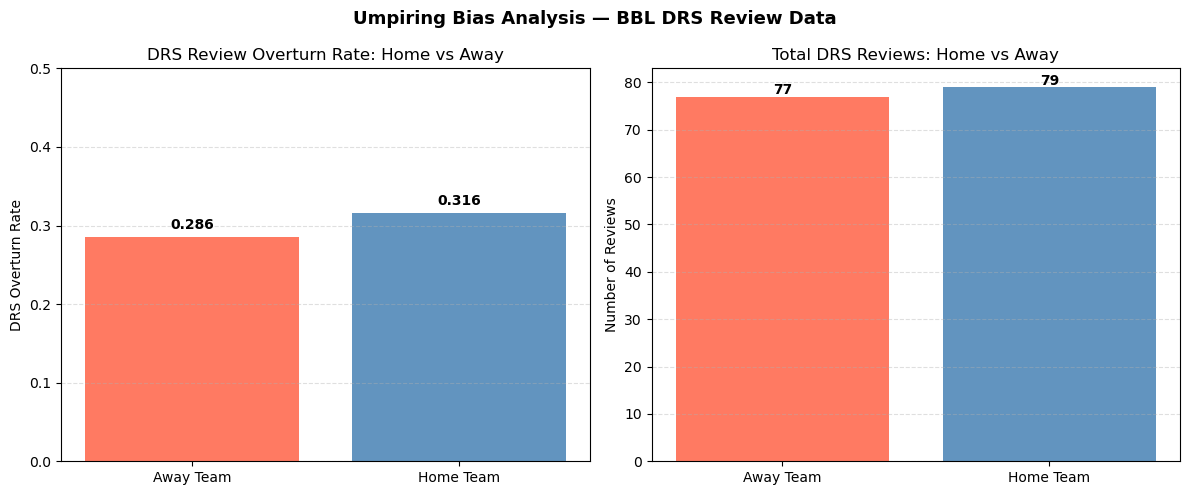

Away overturn rate: 0.286  (22/77)
Home overturn rate: 0.316  (25/79)
Difference:         +0.031
Chi-square test:    chi2=0.059, p=0.807
  Not statistically significant (p >= 0.05) — small sample


In [29]:
import pandas as pd, matplotlib.pyplot as plt
from scipy import stats

reviews_df = pd.read_csv('Downloads/bbl_cleaned/drs_reviews.csv')
reviews_df['is_home_reviewing'] = reviews_df['is_home_reviewing'].astype(bool)

home_df = reviews_df[reviews_df['is_home_reviewing']]
away_df = reviews_df[~reviews_df['is_home_reviewing']]

home_rate, away_rate   = home_df['overturned'].mean(), away_df['overturned'].mean()
home_count, away_count = len(home_df), len(away_df)

labels = ['Away Team', 'Home Team']
values = [away_rate, home_rate]
counts = [away_count, home_count]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, values, color=['tomato','steelblue'], alpha=0.85)
axes[0].set_ylabel('DRS Overturn Rate')
axes[0].set_title('DRS Review Overturn Rate: Home vs Away')
axes[0].set_ylim(0, 0.5)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(values):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(labels, counts, color=['tomato','steelblue'], alpha=0.85)
axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Total DRS Reviews: Home vs Away')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(counts):
    axes[1].text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Umpiring Bias Analysis — BBL DRS Review Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Downloads/bbl_cleaned/umpiring_bias.png', dpi=150)
plt.show()

# Chi-square significance test
contingency = [[int(home_df['overturned'].sum()), home_count - int(home_df['overturned'].sum())],
               [int(away_df['overturned'].sum()), away_count - int(away_df['overturned'].sum())]]
chi2, p_val, _, _ = stats.chi2_contingency(contingency)
print(f"Away overturn rate: {away_rate:.3f}  ({int(away_df['overturned'].sum())}/{away_count})")
print(f"Home overturn rate: {home_rate:.3f}  ({int(home_df['overturned'].sum())}/{home_count})")
print(f"Difference:         {home_rate - away_rate:+.3f}")
print(f"Chi-square test:    chi2={chi2:.3f}, p={p_val:.3f}")
if p_val < 0.05:
    print("  Statistically significant (p < 0.05)")
else:
    print("  Not statistically significant (p >= 0.05) — small sample")


In [30]:
# ── BAYESIAN POSTERIOR PROBABILITIES ─────────────────────────────────────
# Application 1: P(β_is_home > 0 | data) from M4's variational Bayes output
import numpy as np
from scipy import stats

print("=" * 60)
print("BAYESIAN POSTERIOR PROBABILITIES — M4 RESULTS")
print("=" * 60)

# M4 variational Bayes posteriors (posterior mean, posterior SD)
m4_params = {
    'is_home':                  (0.3375, 0.0856),
    'toss_win':                 (0.2236, 0.0827),
    'toss_bat':                 (-0.1059, 0.1291),
    'recent_form_5':            (0.2601, 0.1049),
    'h2h_win_rate':             (0.5009, 0.1140),
    'pp_rr_lag5':               (-0.0057, 0.0079),
    'team_bat_sr_familiarity':  (0.0055, 0.0005),
    'team_bat_avg_familiarity': (-0.0025, 0.0022),
    'team_bowl_eco_familiarity':(-0.1424, 0.0075),
    'team_bowl_sr_familiarity': (-0.0046, 0.0028),
}

print(f"\n{'Predictor':<30} {'Post. Mean':>11} {'Post. SD':>10} {'P(β>0|data)':>13}")
print("-" * 67)
for name, (mu, sd) in m4_params.items():
    # P(β > 0) = 1 - Φ((0 - μ) / σ) = Φ(μ / σ)
    prob = stats.norm.cdf(mu / sd)
    direction = '↑' if mu > 0 else '↓'
    print(f"  {name:<28} {mu:>+11.4f} {sd:>10.4f} {prob*100:>12.2f}%  {direction}")

print()
print("Key finding:")
mu_h, sd_h = m4_params['is_home']
p_home = stats.norm.cdf(mu_h / sd_h)
print(f"  P(β_is_home > 0 | data) = {p_home*100:.4f}%")
print(f"  → There is a {p_home*100:.2f}% posterior probability that")
print(f"    home advantage has a positive effect on win probability.")


BAYESIAN POSTERIOR PROBABILITIES — M4 RESULTS

Predictor                       Post. Mean   Post. SD   P(β>0|data)
-------------------------------------------------------------------
  is_home                          +0.3375     0.0856       100.00%  ↑
  toss_win                         +0.2236     0.0827        99.66%  ↑
  toss_bat                         -0.1059     0.1291        20.60%  ↓
  recent_form_5                    +0.2601     0.1049        99.34%  ↑
  h2h_win_rate                     +0.5009     0.1140       100.00%  ↑
  pp_rr_lag5                       -0.0057     0.0079        23.53%  ↓
  team_bat_sr_familiarity          +0.0055     0.0005       100.00%  ↑
  team_bat_avg_familiarity         -0.0025     0.0022        12.79%  ↓
  team_bowl_eco_familiarity        -0.1424     0.0075         0.00%  ↓
  team_bowl_sr_familiarity         -0.0046     0.0028         5.02%  ↓

Key finding:
  P(β_is_home > 0 | data) = 99.9960%
  → There is a 100.00% posterior probability that
    ho

TEAM-LEVEL BAYESIAN POSTERIOR: P(true home rate > true away rate)

Team                         H W/N    A W/N     Gap   P(home > away)
-------------------------------------------------------------------
  Perth Scorchers         51/75  35/69   +0.173            98.2%
  Adelaide Strikers       42/75  28/66   +0.136            94.5%
  Hobart Hurricanes       41/71  30/68   +0.136            94.5%
  Melbourne Stars         34/64  35/79   +0.088            85.2%
  Sydney Sixers           46/68  42/71   +0.085            84.8%
  Sydney Thunder          29/64  26/71   +0.087            84.7%
  Melbourne Renegades     31/75  27/66   +0.004            51.9%
  Brisbane Heat           30/70  35/72   -0.058            24.7%

Interpretation guide:
  > 95% → strong evidence of genuine home advantage
  75–95% → moderate evidence
  50–75% → weak / uncertain
  < 50%  → data consistent with no home advantage or away advantage


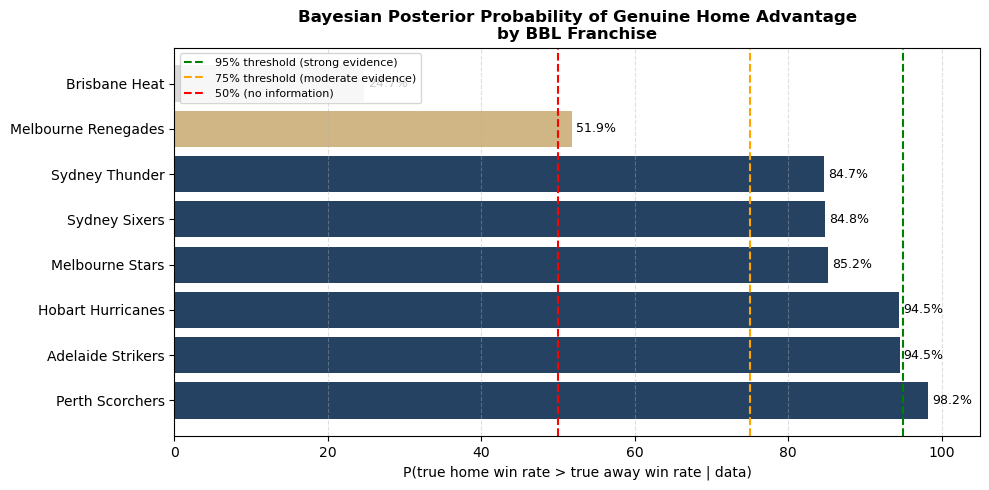

In [31]:
# ── BAYESIAN POSTERIOR PROBABILITIES ─────────────────────────────────────
# Application 2: P(true home win rate > true away win rate) per franchise
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
N = 1_000_000

BASE = "Downloads/bbl_cleaned/"
matches = pd.read_csv(BASE + "cleaned_match_data.csv")
invalid = ['no result','tie','bowl off','bowl-off','abandoned']
matches = matches[
    (~matches['result'].str.lower().isin(invalid)) &
    (matches['winner'].notna()) &
    (matches['home_team'].notna())
].copy()

teams = sorted(matches['home_team'].dropna().unique())
results = []

for team in teams:
    home_m = matches[matches['home_team'] == team]
    away_m = matches[
        ((matches['team1'] == team) | (matches['team2'] == team)) &
        (matches['home_team'] != team)
    ]
    h_wins  = (home_m['winner'] == team).sum()
    h_total = len(home_m)
    a_wins  = (away_m['winner'] == team).sum()
    a_total = len(away_m)

    # Beta posteriors: Beta(1 + wins, 1 + losses)
    home_post = stats.beta(1 + h_wins,  1 + (h_total - h_wins))
    away_post = stats.beta(1 + a_wins,  1 + (a_total - a_wins))

    th = home_post.rvs(N)
    ta = away_post.rvs(N)
    prob = (th > ta).mean()

    results.append({
        'Team': team,
        'Home W': h_wins, 'Home N': h_total,
        'Away W': a_wins, 'Away N': a_total,
        'Home rate': h_wins/h_total,
        'Away rate': a_wins/a_total,
        'Gap': h_wins/h_total - a_wins/a_total,
        'P(home > away)': prob,
    })

df_res = pd.DataFrame(results).sort_values('P(home > away)', ascending=False).reset_index(drop=True)

print("=" * 75)
print("TEAM-LEVEL BAYESIAN POSTERIOR: P(true home rate > true away rate)")
print("=" * 75)
print(f"\n{'Team':<25} {'H W/N':>8} {'A W/N':>8} {'Gap':>7} {'P(home > away)':>16}")
print("-" * 67)
for _, r in df_res.iterrows():
    print(f"  {r['Team']:<23} {int(r['Home W'])}/{int(r['Home N'])}"
          f"  {int(r['Away W'])}/{int(r['Away N'])}"
          f"  {r['Gap']:>+7.3f}  {r['P(home > away)']*100:>14.1f}%")

print()
print("Interpretation guide:")
print("  > 95% → strong evidence of genuine home advantage")
print("  75–95% → moderate evidence")
print("  50–75% → weak / uncertain")
print("  < 50%  → data consistent with no home advantage or away advantage")

# Visualise
NAVY, GOLD = '#002147', '#C8A96E'
fig, ax = plt.subplots(figsize=(10, 5))
colours = [NAVY if p >= 0.75 else GOLD if p >= 0.50 else 'lightgrey'
           for p in df_res['P(home > away)']]
bars = ax.barh(df_res['Team'], df_res['P(home > away)']*100, color=colours, alpha=0.85)
ax.axvline(95, color='green', linestyle='--', linewidth=1.5, label='95% threshold (strong evidence)')
ax.axvline(75, color='orange', linestyle='--', linewidth=1.5, label='75% threshold (moderate evidence)')
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% (no information)')
for bar, val in zip(bars, df_res['P(home > away)']*100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('P(true home win rate > true away win rate | data)')
ax.set_title('Bayesian Posterior Probability of Genuine Home Advantage\nby BBL Franchise', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 105)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(BASE + "team_bayesian_home_advantage.png", dpi=150)
plt.show()


h2h_win_rate: BAYESIAN SHRINKAGE (prior k=5, prior mean=0.50)

Team vs Opponent                         G   W     Raw    Bayes  P(rate>0.5)
------------------------------------------------------------------------


  Melbourne Reneg vs Sydney Sixers      18   4   0.222    0.283         1.5%
  Melbourne Reneg vs Sydney Thunder     18  10   0.556    0.543        66.4%
  Sydney Sixers vs Melbourne Reneg      18  14   0.778    0.717        98.5%
  Perth Scorchers vs Sydney Sixers      28  16   0.571    0.561        75.9%


  Sydney Sixers vs Perth Scorchers      28  12   0.429    0.439        24.0%

Raw rate = wins/games (no shrinkage)
Bayes rate = (wins + 2.5) / (games + 5)  [shrunk toward 0.50]
P(rate > 0.5) = posterior probability this team genuinely dominates this opponent


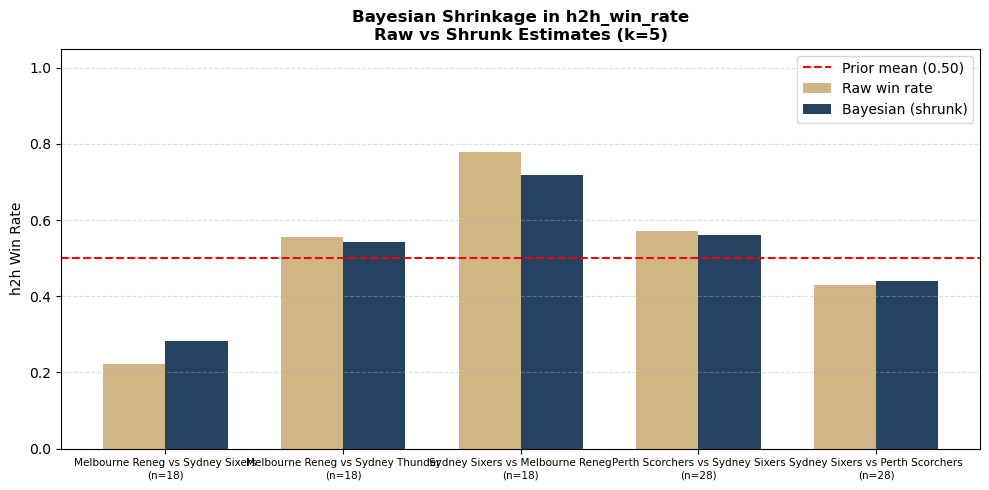

In [32]:
# ── BAYESIAN POSTERIOR PROBABILITIES ─────────────────────────────────────
# Application 3: h2h_win_rate Bayesian shrinkage — prior vs posterior
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

BASE   = "Downloads/bbl_cleaned/"
k      = 5          # shrinkage prior (same as feature engineering)
N_MC   = 1_000_000
np.random.seed(42)

model_df = pd.read_csv(BASE + "model_df_v2.csv")
model_df['date'] = pd.to_datetime(model_df['date'])

# Pick 6 illustrative team pairs (mix of high/low game counts)
pairs_raw = (model_df.groupby(['team','opponent'])
             .agg(games=('win','count'), wins=('win','sum'))
             .reset_index())
pairs_raw = pairs_raw[pairs_raw['games'] >= 1].copy()
pairs_raw['raw_rate'] = pairs_raw['wins'] / pairs_raw['games']
pairs_raw['bayes_rate'] = (pairs_raw['wins'] + k*0.5) / (pairs_raw['games'] + k)

# Select a spread of sample sizes
sample = pd.concat([
    pairs_raw.nsmallest(3, 'games'),
    pairs_raw[pairs_raw['games'].between(8,12)].head(2),
    pairs_raw.nlargest(2, 'games'),
]).drop_duplicates().reset_index(drop=True)

print("=" * 72)
print("h2h_win_rate: BAYESIAN SHRINKAGE (prior k=5, prior mean=0.50)")
print("=" * 72)
print(f"\n{'Team vs Opponent':<38} {'G':>3} {'W':>3} {'Raw':>7} {'Bayes':>8} {'P(rate>0.5)':>12}")
print("-" * 72)

results_h2h = []
for _, r in sample.iterrows():
    label = f"{r['team'][:15]} vs {r['opponent'][:15]}"
    # Posterior: Beta(k/2 + wins, k/2 + losses)
    post = stats.beta(k/2 + r['wins'], k/2 + (r['games'] - r['wins']))
    prob = (post.rvs(N_MC) > 0.5).mean()
    print(f"  {label:<36} {int(r['games']):>3} {int(r['wins']):>3} "
          f"{r['raw_rate']:>7.3f} {r['bayes_rate']:>8.3f}  {prob*100:>10.1f}%")
    results_h2h.append({'label': label, 'games': r['games'],
                         'raw': r['raw_rate'], 'bayes': r['bayes_rate'], 'prob': prob})

print()
print("Raw rate = wins/games (no shrinkage)")
print("Bayes rate = (wins + 2.5) / (games + 5)  [shrunk toward 0.50]")
print("P(rate > 0.5) = posterior probability this team genuinely dominates this opponent")

# Visualise shrinkage
NAVY, GOLD = '#002147', '#C8A96E'
fig, ax = plt.subplots(figsize=(10, 5))
df_h = pd.DataFrame(results_h2h).sort_values('games')
x = np.arange(len(df_h))
w = 0.35
ax.bar(x - w/2, df_h['raw'],   w, color=GOLD, alpha=0.85, label='Raw win rate')
ax.bar(x + w/2, df_h['bayes'], w, color=NAVY, alpha=0.85, label='Bayesian (shrunk)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Prior mean (0.50)')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['label']}\n(n={int(r['games'])})" for _, r in df_h.iterrows()],
                   fontsize=7.5)
ax.set_ylabel('h2h Win Rate')
ax.set_title('Bayesian Shrinkage in h2h_win_rate\nRaw vs Shrunk Estimates (k=5)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(BASE + "h2h_bayesian_shrinkage.png", dpi=150)
plt.show()


---
## Robustness Checks

Two additional robustness checks to validate the central `is_home` finding:

1. **Primary venues only** — re-estimate M1 and M2 after restricting to each team's established primary home ground, excluding secondary/outreach venues (GMHBA Geelong, Carrara Oval, Manuka Oval, Stadium Australia).
2. **Season-by-season stability** — estimate `is_home` OR and 95% CI for each BBL season separately to test whether the effect is temporally consistent or driven by a few outlier seasons.

### Robustness Check 1: Primary Venues Only

Re-run M1 and M2 on matches played exclusively at each team's primary home ground, excluding outreach/secondary venues where home-team classification is less reliable.

In [61]:
# ── ROBUSTNESS CHECK 1: PRIMARY VENUES ONLY ─────────────────────────────────
# Filter at MATCH level: include a match only if the home team is playing at
# their established primary ground. Both rows (home + away perspective) are
# kept for qualifying matches — this preserves the two-row structure.
#
# Secondary venues excluded:
#   - Manuka Oval (Thunder/Sixers outreach + COVID hub)
#   - Carrara Oval (Heat Gold Coast outreach + COVID hub)
#   - GMHBA Stadium, Geelong (Renegades outreach)
#   - Stadium Australia (shared; not a dedicated primary ground)
#   - Aurora/UTAS Stadium, Launceston (Hurricanes secondary)

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Downloads/bbl_cleaned/model_df_v2.csv")
matches = pd.read_csv("Downloads/bbl_cleaned/cleaned_match_data.csv")
df['date'] = pd.to_datetime(df['date'])

# Merge venue + home_team at match level
df = df.merge(
    matches[['match_id','venue','home_team']].drop_duplicates(),
    on='match_id', how='left')

PRIMARY_VENUES = {
    'Adelaide Strikers':   ['Adelaide Oval'],
    'Brisbane Heat':       ['Brisbane Cricket Ground, Woolloongabba, Brisbane'],
    'Hobart Hurricanes':   ['Bellerive Oval, Hobart'],
    'Melbourne Renegades': ['Docklands Stadium, Melbourne'],
    'Melbourne Stars':     ['Melbourne Cricket Ground'],
    'Perth Scorchers':     ['Western Australia Cricket Association Ground', 'Perth Stadium'],
    'Sydney Sixers':       ['Sydney Cricket Ground, Sydney'],
    'Sydney Thunder':      ['Sydney Showground Stadium'],
}

# Identify matches where the home team is at their primary ground
match_meta = df.drop_duplicates('match_id')
primary_ids = match_meta[
    match_meta.apply(
        lambda r: r['venue'] in PRIMARY_VENUES.get(r['home_team'], []), axis=1)
]['match_id']

df_primary = df[df['match_id'].isin(primary_ids)].copy()

print(f"Full dataset:         {df['match_id'].nunique()} matches  ({len(df)} rows)")
print(f"Primary venues only:  {df_primary['match_id'].nunique()} matches  ({len(df_primary)} rows)")
print(f"Excluded (secondary): {df['match_id'].nunique() - df_primary['match_id'].nunique()} matches")
print()

PREDICTORS = ('is_home + toss_win + toss_bat + recent_form_5 + h2h_win_rate + '
              'pp_rr_lag5 + team_bat_sr_familiarity + team_bat_avg_familiarity + '
              'team_bowl_eco_familiarity + team_bowl_sr_familiarity')

results = []
for subset, label in [(df, 'Full dataset'), (df_primary, 'Primary venues only')]:
    for mname, formula in [('M1', 'win ~ is_home'), ('M2', f'win ~ {PREDICTORS}')]:
        m    = smf.logit(formula, data=subset).fit(method='bfgs', maxiter=300, disp=False)
        coef = m.params['is_home']
        OR   = np.exp(coef)
        ci   = np.exp(m.conf_int().loc['is_home'])
        pval = m.pvalues['is_home']
        n    = subset['match_id'].nunique()
        sig  = '***' if pval<0.01 else ('**' if pval<0.05 else ('†' if pval<0.10 else ''))
        results.append({'Subset': label, 'Model': mname, 'N': n,
                        'OR': round(OR,3), '95% CI': f"({ci[0]:.3f},{ci[1]:.3f})",
                        'p': round(pval,4), 'Sig': sig})

res_df = pd.DataFrame(results)
print("Table: is_home robustness — primary venues vs full dataset")
print(res_df.to_string(index=False))
print()

# Full M2 predictor table for primary venues only
m2p = smf.logit(f'win ~ {PREDICTORS}', data=df_primary).fit(method='bfgs', maxiter=300, disp=False)
pred_df = pd.DataFrame({'Coef': m2p.params, 'SE': m2p.bse,
                         'p': m2p.pvalues, 'OR': np.exp(m2p.params)}).drop('Intercept')
pred_df['Sig'] = pred_df['p'].apply(
    lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')))
print("M2 full predictor table — primary venues only:")
print(pred_df.round(4).to_string())


Full dataset:         604 matches  (1208 rows)
Primary venues only:  494 matches  (988 rows)
Excluded (secondary): 110 matches

Table: is_home robustness — primary venues vs full dataset
             Subset Model   N    OR        95% CI      p Sig
       Full dataset    M1 604 1.359 (1.083,1.705) 0.0080 ***
       Full dataset    M2 604 1.391 (1.103,1.755) 0.0053 ***
Primary venues only    M1 494 1.526 (1.187,1.961) 0.0010 ***
Primary venues only    M2 494 1.543 (1.193,1.995) 0.0010 ***

M2 full predictor table — primary venues only:
                             Coef      SE       p      OR  Sig
is_home                    0.4335  0.1312  0.0010  1.5427  ***
toss_win                   0.3838  0.1512  0.0111  1.4678   **
toss_bat                  -0.1644  0.1860  0.3767  0.8484     
recent_form_5              0.3697  0.2803  0.1872  1.4473     
h2h_win_rate               1.2465  0.6315  0.0484  3.4781   **
pp_rr_lag5                -0.0164  0.0704  0.8162  0.9838     
team_bat_sr_familia

### Robustness Check 2: Season-by-Season Stability

Estimate the `is_home` odds ratio and 95% confidence interval separately for each BBL season. A consistent positive effect across the majority of seasons provides strong evidence that the finding is not driven by any single season or time period.

Season-by-season is_home estimates (M1: win ~ is_home):
 Season  N  Home win%    OR  CI lower  CI upper  p-value
2011/12 27       55.6 1.562     0.534     4.571   0.4152
2012/13 28       42.9 0.563     0.195     1.621   0.2867
2013/14 32       50.0 1.000     0.375     2.664   1.0000
2014/15 32       50.0 1.000     0.375     2.664   1.0000
2015/16 32       43.8 0.605     0.225     1.624   0.3186
2016/17 34       38.2 0.383     0.144     1.019   0.0546
2017/18 43       59.5 2.124     0.898     5.023   0.0862
2018/19 58       57.1 1.744     0.836     3.638   0.1384
2019/20 58       44.4 0.659     0.316     1.372   0.2649
2020/21 60       65.9 2.806     1.295     6.081   0.0089
2021/22 60       48.9 0.932     0.448     1.941   0.8516
2022/23 60       66.1 3.471     1.635     7.370   0.0012
2023/24 39       54.1 1.362     0.559     3.322   0.4967
2024/25 41       68.3 4.639     1.830    11.761   0.0012

OR > 1 (positive home advantage): 7/14 seasons
Significant (p < 0.05):           3/14 se

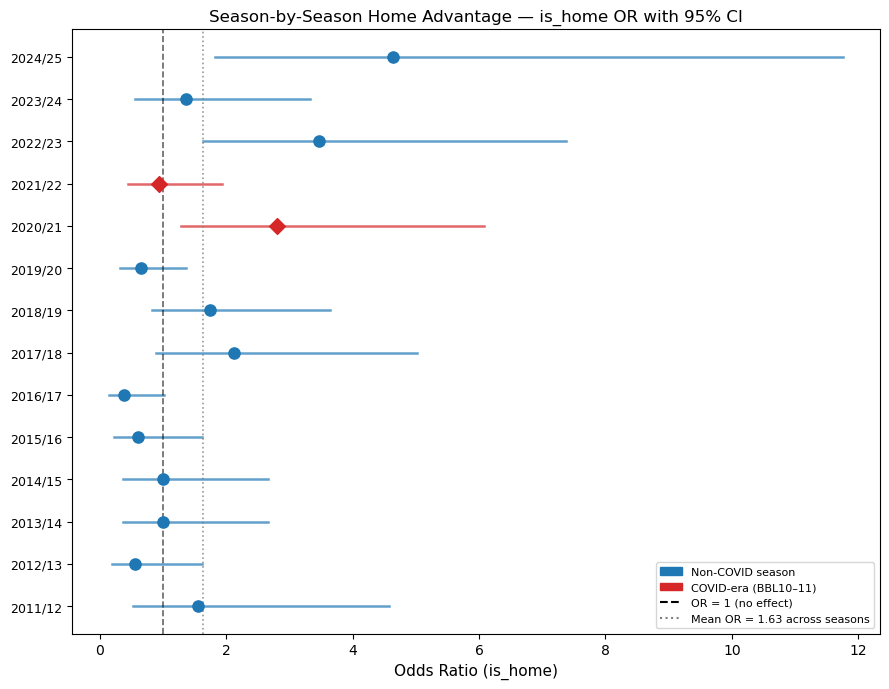

Forest plot saved: Downloads/bbl_cleaned/robustness_season_forest.png


In [64]:
# ── ROBUSTNESS CHECK 2: SEASON-BY-SEASON is_home STABILITY ──────────────────
# Estimate is_home OR + 95% CI separately for each BBL season using M1.
# Early seasons have 27–34 matches each; power is too low for individual
# significance. The forest plot visualises whether the direction is consistent
# across seasons, which is the relevant test.

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Downloads/bbl_cleaned/model_df_v2.csv")
df['date'] = pd.to_datetime(df['date'])

def season_label(dt):
    yr = dt.year if dt.month >= 10 else dt.year - 1
    return f"{yr}/{str(yr+1)[-2:]}"

df['season'] = df['date'].apply(season_label)
COVID_SEASONS = {'2020/21', '2021/22'}

rows = []
for s in sorted(df['season'].unique()):
    sub = df[df['season'] == s]
    n   = sub['match_id'].nunique()
    if n < 8:
        continue
    try:
        m    = smf.logit('win ~ is_home', data=sub).fit(method='bfgs', disp=False)
        coef = m.params['is_home']
        OR   = np.exp(coef)
        ci   = np.exp(m.conf_int().loc['is_home'])
        pval = m.pvalues['is_home']
        hw   = sub[sub['is_home']==1]['win'].mean()
        rows.append({'Season': s, 'N': n, 'Home win%': round(hw*100,1),
                     'OR': round(OR,3), 'CI_lo': round(ci[0],3),
                     'CI_hi': round(ci[1],3), 'p': round(pval,4),
                     'covid': s in COVID_SEASONS})
    except Exception:
        pass

sdf = pd.DataFrame(rows)
print("Season-by-season is_home estimates (M1: win ~ is_home):")
display_df = sdf[['Season','N','Home win%','OR','CI_lo','CI_hi','p']].copy()
display_df.columns = ['Season','N','Home win%','OR','CI lower','CI upper','p-value']
print(display_df.to_string(index=False))
print()
print(f"OR > 1 (positive home advantage): {(sdf['OR']>1).sum()}/{len(sdf)} seasons")
print(f"Significant (p < 0.05):           {(sdf['p']<0.05).sum()}/{len(sdf)} seasons")
print(f"Note: seasons 2011/12–2016/17 have 27–34 matches each (underpowered individually)")

# ── Forest plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for i, row in sdf.iterrows():
    idx  = sdf.index.get_loc(i)
    col  = '#d62728' if row['covid'] else '#1f77b4'
    mark = 'D' if row['covid'] else 'o'
    ax.plot([row['CI_lo'], row['CI_hi']], [idx, idx], color=col, lw=1.8, alpha=0.7)
    ax.scatter(row['OR'], idx, color=col, zorder=5, s=65, marker=mark)

mean_or = sdf['OR'].mean()
ax.axvline(1.0, color='black', linestyle='--', lw=1.2, alpha=0.6)
ax.axvline(mean_or, color='grey', linestyle=':', lw=1.2, alpha=0.8)

ax.set_yticks(range(len(sdf)))
ax.set_yticklabels(sdf['Season'], fontsize=9)
ax.set_xlabel('Odds Ratio (is_home)', fontsize=11)
ax.set_title('Season-by-Season Home Advantage — is_home OR with 95% CI', fontsize=12)

handles = [
    mpatches.Patch(color='#1f77b4', label='Non-COVID season'),
    mpatches.Patch(color='#d62728', label='COVID-era (BBL10–11)'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='OR = 1 (no effect)'),
    plt.Line2D([0],[0], color='grey',  linestyle=':',
               label=f'Mean OR = {mean_or:.2f} across seasons'),
]
ax.legend(handles=handles, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig("Downloads/bbl_cleaned/robustness_season_forest.png", dpi=150, bbox_inches='tight')
plt.show()
print("Forest plot saved: Downloads/bbl_cleaned/robustness_season_forest.png")
